# 📊 Mid-Cap Mutual Fund Portfolio Analysis
### Top 10 Mid-Cap Funds by AUM — Nov 2025 to Apr 2026
**Objective:** Identify common holdings and track whether fund managers are consistently accumulating or reducing stocks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

FILE = 'Midcap.xlsx'

FUNDS = [
    'HDFC', 'KOTAK', 'NIPPON', 'MOTILAL OSWAL', 'AXIS',
    'SBI', 'DSP', 'MIRAE ASSET', 'EDELWEISS', 'HSBC'
]

MONTHS_ORDER = ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']

NON_STOCK = [
    'AUM',
    'Cash and Other Receivables',
    'NIFTY',
    'MIDCAPNIFTY 30/12/2025'
]

raw_data = {}
aum_data = {}

def convert_month_col(col):
    """
    Converts Excel columns like:
    Apr-26 -> 2026-04
    Mar-26 -> 2026-03
    Dec-25 -> 2025-12
    """
    if col == 'Security Name':
        return col
    
    try:
        return pd.to_datetime(str(col), format='%b-%y').strftime('%Y-%m')
    except:
        try:
            return pd.to_datetime(col).strftime('%Y-%m')
        except:
            return str(col).strip()


for fund in FUNDS:
    df = pd.read_excel(FILE, sheet_name=fund, na_values=['-', '–', ''])
    
    # Clean column names
    df.columns = [convert_month_col(c) for c in df.columns]
    
    # Clean security names
    df['Security Name'] = df['Security Name'].astype(str).str.strip()
    
    # Extract AUM row
    aum_row = df[df['Security Name'].str.upper() == 'AUM']
    if not aum_row.empty:
        aum_data[fund] = aum_row.iloc[0, 1:].to_dict()
    
    # Remove non-stock rows
    df = df[~df['Security Name'].isin(NON_STOCK)].copy()
    df = df.dropna(subset=['Security Name'])
    
    # Remove blank / nan names
    df = df[~df['Security Name'].isin(['nan', 'None', ''])]
    
    # Set index
    df = df.set_index('Security Name')
    
    # Keep only required months
    month_cols = [m for m in MONTHS_ORDER if m in df.columns]
    df = df[month_cols]
    
    # Convert values to numeric
    df = df.apply(pd.to_numeric, errors='coerce')
    
    raw_data[fund] = df

print('✅ Data loaded for funds:', list(raw_data.keys()))

print('\n📅 Months available per fund:')
for f, d in raw_data.items():
    print(f'  {f}: {list(d.columns)}')

print('\n✅ Sample check:')
for f, d in raw_data.items():
    print(f'\n{f}')
    print(d.head())

✅ Data loaded for funds: ['HDFC', 'KOTAK', 'NIPPON', 'MOTILAL OSWAL', 'AXIS', 'SBI', 'DSP', 'MIRAE ASSET', 'EDELWEISS', 'HSBC']

📅 Months available per fund:
  HDFC: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  KOTAK: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  NIPPON: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  MOTILAL OSWAL: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  AXIS: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  SBI: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  DSP: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  MIRAE ASSET: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  EDELWEISS: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  HSBC: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']

✅ Sample check:

HDFC
                                  2025-11  2025

---
## Analysis 1 — Common Holdings Across Funds
**Question:** Which stocks are held by how many small-cap funds at the same time?

📋 Holdings Distribution Table — Apr 2026


,# Funds Holding,Stock Count,Stocks
0,9,3,"Bharat Forge Limited, The Federal Bank Limited, Dixon Technologies (India) Limited"
1,8,4,"Persistent Systems Limited, Schaeffler India Limited, Multi Commodity Exchange of India Limited, Max Financial Servi..."
2,7,6,"JK Cement Limited, Hindustan Petroleum Corporation Limited, Ipca Laboratories Limited, PB Fintech Limited, Eternal L..."
3,6,13,"Bharat Heavy Electricals Limited, Bharat Electronics Limited, Bharti Hexacom Limited, KEI Industries Limited, Suprem..."
4,5,24,"Coromandel International Limited, Page Industries Limited, LG Electronics India Limited, Blue Star Limited, Polycab ..."
5,4,26,"Cholamandalam Financial Holdings Limited, Gujarat Fluorochemicals Limited, Radico Khaitan Limited, Lenskart Solution..."
6,3,25,"Endurance Technologies Limited, Aster DM Healthcare Limited, UNO Minda Limited, Apollo Tyres Limited, KPIT Technolog..."
7,2,56,"Glenmark Pharmaceuticals Limited, Marico Limited, Aurobindo Pharma Limited, Home First Finance Company India Limited..."
8,1,111,"Godfrey Phillips India Limited, KFin Technologies Limited, Aditya Infotech Limited, Firstsource Solutions Limited, M..."


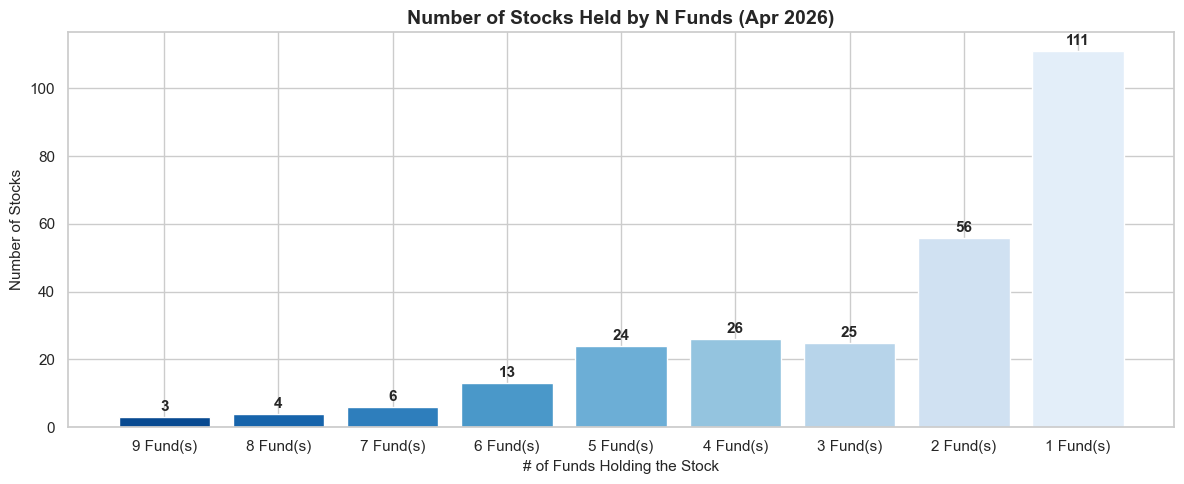

In [2]:
# For each stock, count how many funds hold it in Apr-26 (latest month)
LATEST = '2026-04'

stock_fund_count = {}
for fund, df in raw_data.items():
    if LATEST in df.columns:
        held = df[LATEST].dropna()
        held = held[held > 0]
        for stock in held.index:
            stock_fund_count[stock] = stock_fund_count.get(stock, 0) + 1

count_series = pd.Series(stock_fund_count).sort_values(ascending=False)

# Build table: rows = stocks, col = # of funds (1 to 10)
max_funds = 10
common_table_rows = []
for n_funds in range(max_funds, 0, -1):
    stocks_at_n = count_series[count_series == n_funds].index.tolist()
    common_table_rows.append({'# Funds Holding': n_funds, 'Stock Count': len(stocks_at_n), 'Stocks': ', '.join(stocks_at_n)})

common_table = pd.DataFrame(common_table_rows)
common_table = common_table[common_table['Stock Count'] > 0].reset_index(drop=True)

print('📋 Holdings Distribution Table — Apr 2026')
print('=' * 80)
pd.set_option('display.max_colwidth', 120)
display(common_table)

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(common_table['# Funds Holding'].astype(str) + ' Fund(s)', common_table['Stock Count'],
              color=sns.color_palette('Blues_r', len(common_table)))
ax.bar_label(bars, padding=2, fontsize=11, fontweight='bold')
ax.set_title('Number of Stocks Held by N Funds (Apr 2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('# of Funds Holding the Stock', fontsize=11)
ax.set_ylabel('Number of Stocks', fontsize=11)
plt.tight_layout()
plt.show()

In [3]:
# Top 20 stocks by number of funds holding them in Apr-26

top20_common_stocks = (
    count_series
    .reset_index()
    .rename(columns={"index": "Stock", 0: "Number of Funds Holding"})
    .sort_values(["Number of Funds Holding", "Stock"], ascending=[False, True])
    .head(20)
    .reset_index(drop=True)
)

print("🏆 Top 20 Stocks by Number of Funds Holding — Apr 2026")
display(top20_common_stocks)

🏆 Top 20 Stocks by Number of Funds Holding — Apr 2026


,Stock,Number of Funds Holding
0,Bharat Forge Limited,9
1,Dixon Technologies (India) Limited,9
2,The Federal Bank Limited,9
3,Max Financial Services Limited,8
4,Multi Commodity Exchange of India Limited,8
5,Persistent Systems Limited,8
6,Schaeffler India Limited,8
7,AU Small Finance Bank Limited,7
8,Eternal Limited,7
9,Hindustan Petroleum Corporation Limited,7


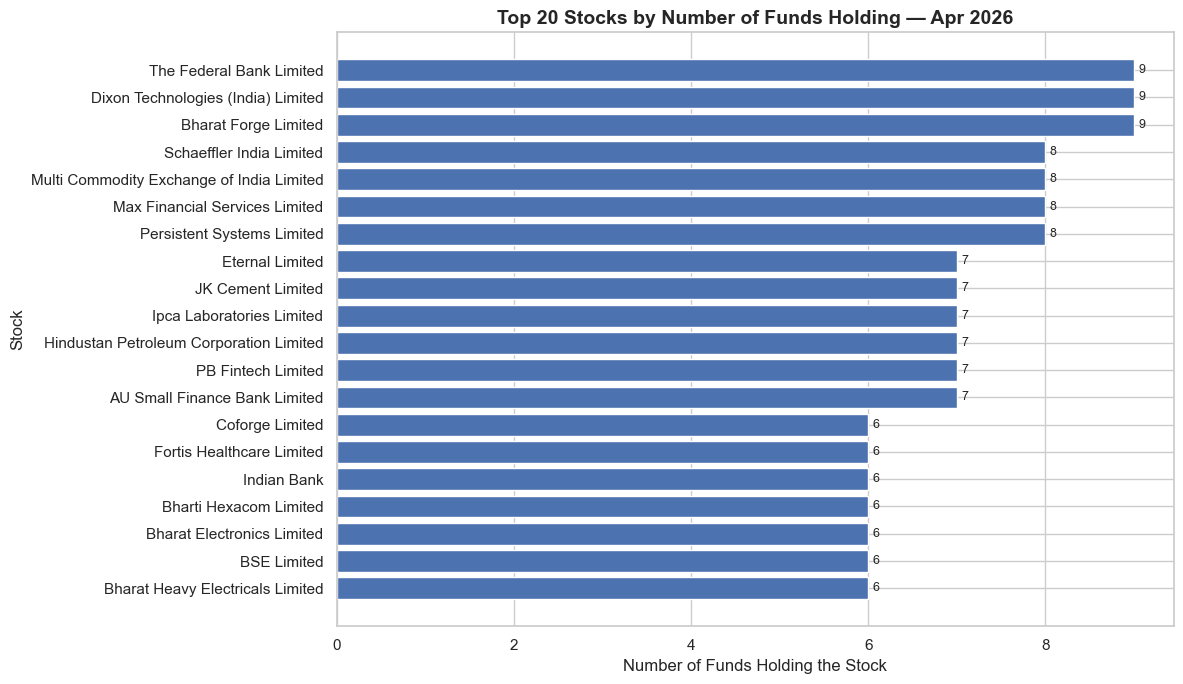

In [4]:
# Graph — Top 20 common holdings

plot_df = top20_common_stocks.sort_values(
    "Number of Funds Holding",
    ascending=True
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    plot_df["Stock"],
    plot_df["Number of Funds Holding"]
)

ax.bar_label(
    bars,
    labels=[f"{v:.0f}" for v in plot_df["Number of Funds Holding"]],
    padding=3,
    fontsize=9
)

ax.set_title(
    "Top 20 Stocks by Number of Funds Holding — Apr 2026",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Number of Funds Holding the Stock")
ax.set_ylabel("Stock")

plt.subplots_adjust(left=0.38, right=0.95)
plt.tight_layout()
plt.show()

---
## Analysis 2 — Top 10 Common Holdings (Apr-26 to Nov-25)
**Question:** Which stocks appear repeatedly in the top 10 holdings across funds?

In [5]:
# Count holding appearances across all funds and all months
# Meaning: stock has positive AUM in a fund-month

holding_appearances = {}

for fund, df in raw_data.items():
    
    df = df.copy()
    df = df.replace("-", np.nan)
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # Combine duplicate stock names if any
    df = df.groupby(df.index).sum(numeric_only=True)
    
    for month in MONTHS_ORDER:
        if month in df.columns:
            
            held = df[month].dropna()
            held = held[held > 0]
            
            for stock in held.index:
                holding_appearances[stock] = holding_appearances.get(stock, 0) + 1

holding_series = pd.Series(holding_appearances).sort_values(ascending=False)

holding_df = pd.DataFrame({
    "Stock": holding_series.index,
    "Holding Appearances (All Funds × All Months)": holding_series.values
})

holding_df.index = range(1, len(holding_df) + 1)

print("🏆 Top 20 Stocks by Holding Appearances")
print("Maximum possible = 10 funds × 6 months = 60")
display(holding_df.head(20))

🏆 Top 20 Stocks by Holding Appearances
Maximum possible = 10 funds × 6 months = 60


,Stock,Holding Appearances (All Funds × All Months)
1,Bharat Forge Limited,54
2,The Federal Bank Limited,54
3,Dixon Technologies (India) Limited,52
4,Persistent Systems Limited,48
5,Max Financial Services Limited,48
6,Hindustan Petroleum Corporation Limited,45
7,Schaeffler India Limited,44
8,Ipca Laboratories Limited,42
9,JK Cement Limited,42
10,Eternal Limited,42


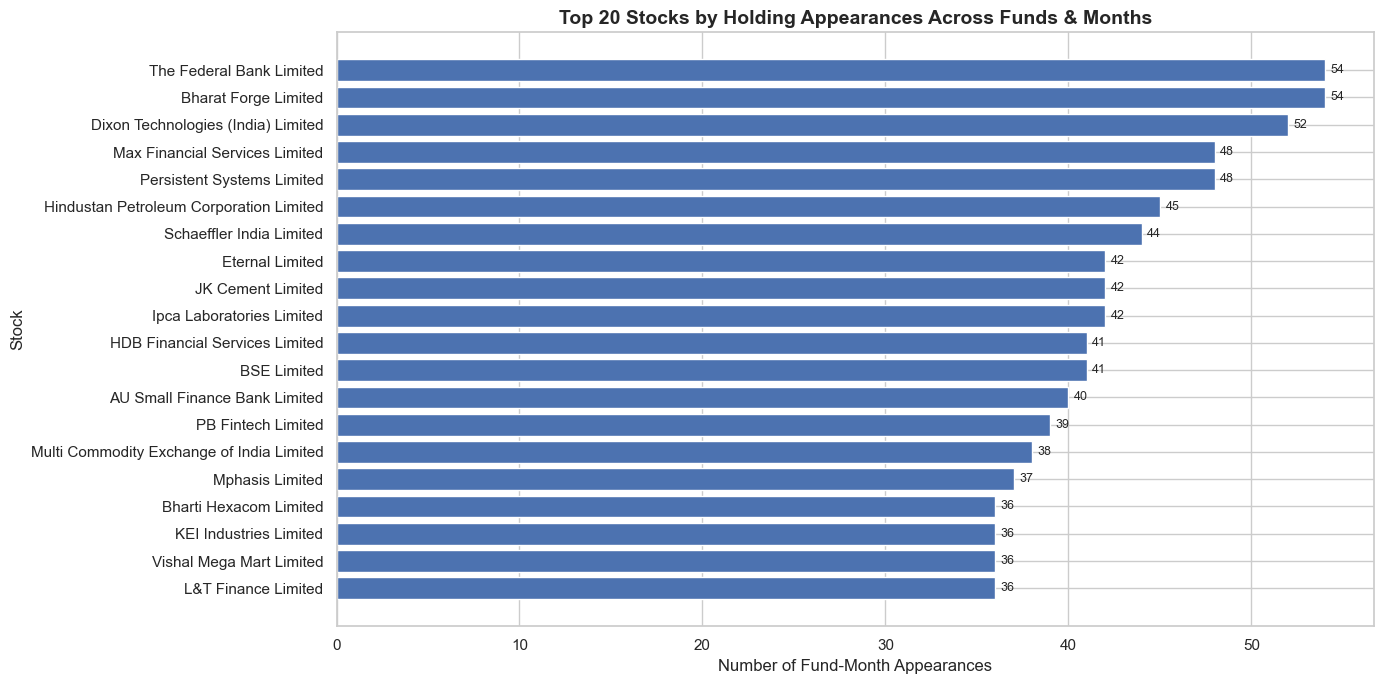

In [6]:
# Chart — Top 20 holding appearances

top20_holding_series = holding_series.head(20)

fig, ax = plt.subplots(figsize=(14, 7))

plot_series = top20_holding_series.sort_values(ascending=True)

bars = ax.barh(
    plot_series.index,
    plot_series.values
)

ax.bar_label(
    bars,
    labels=[f"{v:.0f}" for v in plot_series.values],
    padding=4,
    fontsize=9
)

ax.set_title(
    "Top 20 Stocks by Holding Appearances Across Funds & Months",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Number of Fund-Month Appearances")
ax.set_ylabel("Stock")

plt.subplots_adjust(left=0.35, right=0.95)
plt.tight_layout()
plt.show()

---
## Analysis 3 — Fund Overlap Matrix
**Question:** Which funds have similar portfolios? Which provide real diversification?

📊 Fund Overlap Matrix — Common Stock Count (Apr-26)
  (Diagonal = total holdings of the fund)


,HDFC,KOTAK,NIPPON,MOTILAL OSWAL,AXIS,SBI,DSP,MIRAE ASSET,EDELWEISS,HSBC
HDFC,76,21,32,8,30,11,25,17,26,18
KOTAK,21,64,31,9,34,11,28,17,26,27
NIPPON,32,31,97,12,55,23,31,29,45,34
MOTILAL OSWAL,8,9,12,27,18,1,11,10,17,17
AXIS,30,34,55,18,87,21,37,24,51,40
SBI,11,11,23,1,21,49,12,14,19,17
DSP,25,28,31,11,37,12,61,17,27,24
MIRAE ASSET,17,17,29,10,24,14,17,62,25,18
EDELWEISS,26,26,45,17,51,19,27,25,89,43
HSBC,18,27,34,17,40,17,24,18,43,87


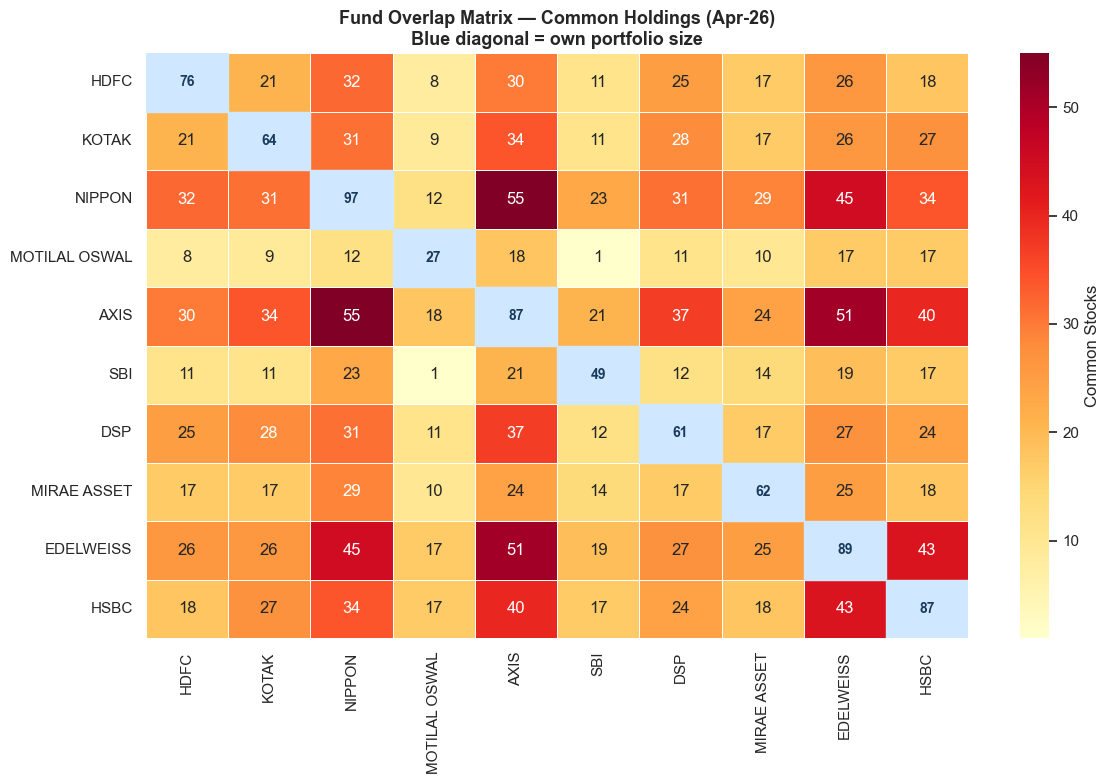


📐 Jaccard Similarity Matrix (% overlap — higher = more similar)


,HDFC,KOTAK,NIPPON,MOTILAL OSWAL,AXIS,SBI,DSP,MIRAE ASSET,EDELWEISS,HSBC
HDFC,100.0,17.6,22.7,8.4,22.6,9.6,22.3,14.0,18.7,12.4
KOTAK,17.6,100.0,23.8,11.0,29.1,10.8,28.9,15.6,20.5,21.8
NIPPON,22.7,23.8,100.0,10.7,42.6,18.7,24.4,22.3,31.9,22.7
MOTILAL OSWAL,8.4,11.0,10.7,100.0,18.8,1.3,14.3,12.7,17.2,17.5
AXIS,22.6,29.1,42.6,18.8,100.0,18.3,33.3,19.2,40.8,29.9
SBI,9.6,10.8,18.7,1.3,18.3,100.0,12.2,14.4,16.0,14.3
DSP,22.3,28.9,24.4,14.3,33.3,12.2,100.0,16.0,22.0,19.4
MIRAE ASSET,14.0,15.6,22.3,12.7,19.2,14.4,16.0,100.0,19.8,13.7
EDELWEISS,18.7,20.5,31.9,17.2,40.8,16.0,22.0,19.8,100.0,32.3
HSBC,12.4,21.8,22.7,17.5,29.9,14.3,19.4,13.7,32.3,100.0


In [8]:
# Overlap = number of common stocks held in Apr-26
END_MONTH = '2026-04'
holdings_apr = {}
for fund, df in raw_data.items():
    if END_MONTH in df.columns:
        held = set(df[END_MONTH].dropna()[df[END_MONTH].dropna() > 0].index)
        holdings_apr[fund] = held

fund_list = list(holdings_apr.keys())
n = len(fund_list)

# Common stock count matrix
overlap_matrix = pd.DataFrame(0, index=fund_list, columns=fund_list)
for f1, f2 in combinations(fund_list, 2):
    common = len(holdings_apr[f1] & holdings_apr[f2])
    overlap_matrix.loc[f1, f2] = common
    overlap_matrix.loc[f2, f1] = common
for f in fund_list:
    overlap_matrix.loc[f, f] = len(holdings_apr[f])

print('📊 Fund Overlap Matrix — Common Stock Count (Apr-26)')
print('  (Diagonal = total holdings of the fund)')
display(overlap_matrix)

# Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
mask = np.eye(n, dtype=bool)
sns.heatmap(overlap_matrix, annot=True, fmt='d', cmap='YlOrRd', mask=mask,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Common Stocks'})
# Diagonal with different color
for i in range(n):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='#d0e8ff', zorder=3))
    ax.text(i + 0.5, i + 0.5, str(overlap_matrix.iloc[i, i]),
            ha='center', va='center', fontsize=10, fontweight='bold', color='#1a3a5c', zorder=4)
ax.set_title('Fund Overlap Matrix — Common Holdings (Apr-26)\nBlue diagonal = own portfolio size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Also: % overlap (Jaccard similarity)
jaccard_matrix = pd.DataFrame(0.0, index=fund_list, columns=fund_list)

for f1, f2 in combinations(fund_list, 2):
    union = len(holdings_apr[f1] | holdings_apr[f2])
    inter = len(holdings_apr[f1] & holdings_apr[f2])
    jaccard = inter / union if union > 0 else 0
    
    jaccard_matrix.loc[f1, f2] = round(jaccard * 100, 1)
    jaccard_matrix.loc[f2, f1] = round(jaccard * 100, 1)

for f in fund_list:
    jaccard_matrix.loc[f, f] = 100.0



# Column sum
column_sum = jaccard_matrix.sum(axis=0)
jaccard_matrix.loc["Column Sum"] = column_sum

print('\n📐 Jaccard Similarity Matrix (% overlap — higher = more similar)')
display(jaccard_matrix)

---
## Analysis 4 — Stock Popularity Ranking
**Question:** Which stocks are most popular among small-cap fund managers across all months?

🌟 Stock Popularity Ranking (Average # of Funds Holding — Nov-25 to Apr-26)


,Stock,Avg Funds Holding,Max Funds Holding
Rank,,,
1,The Federal Bank Limited,9.0,9
2,Bharat Forge Limited,9.0,9
3,Dixon Technologies (India) Limited,8.7,9
4,Persistent Systems Limited,8.0,8
5,Max Financial Services Limited,8.0,8
6,Hindustan Petroleum Corporation Limited,7.5,8
7,Schaeffler India Limited,7.3,8
8,Ipca Laboratories Limited,7.0,7
9,JK Cement Limited,7.0,7


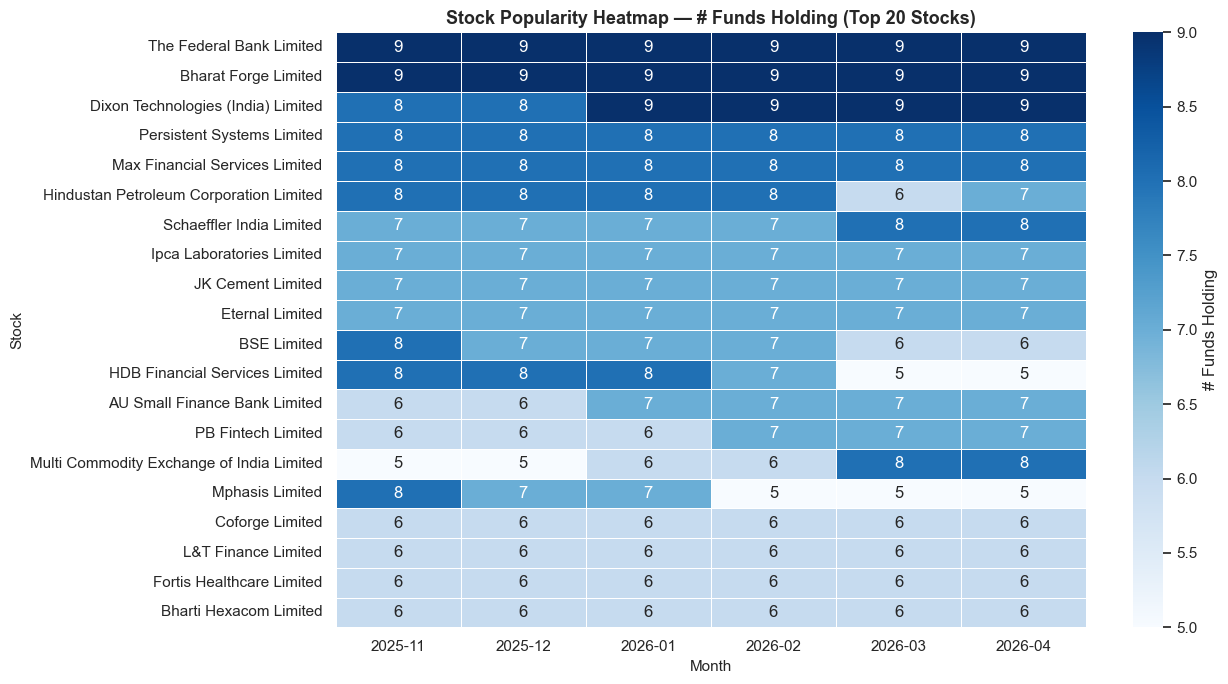

In [9]:
# Build monthly popularity: for each month, count how many funds hold each stock
popularity_records = []
for month in MONTHS_ORDER:
    month_counts = {}
    for fund, df in raw_data.items():
        if month in df.columns:
            held = df[month].dropna()
            held = held[held > 0]
            for stock in held.index:
                month_counts[stock] = month_counts.get(stock, 0) + 1
    for stock, cnt in month_counts.items():
        popularity_records.append({'Month': month, 'Stock': stock, 'Funds Holding': cnt})

pop_df = pd.DataFrame(popularity_records)

# Average popularity across all months
avg_pop = pop_df.groupby('Stock')['Funds Holding'].mean().sort_values(ascending=False)
max_pop = pop_df.groupby('Stock')['Funds Holding'].max()

pop_rank = pd.DataFrame({
    'Stock': avg_pop.index,
    'Avg Funds Holding': avg_pop.values.round(1),
    'Max Funds Holding': max_pop.reindex(avg_pop.index).values
}).reset_index(drop=True)
pop_rank.index = range(1, len(pop_rank)+1)
pop_rank.index.name = 'Rank'

print('🌟 Stock Popularity Ranking (Average # of Funds Holding — Nov-25 to Apr-26)')
display(pop_rank.head(30))

# Monthly popularity heatmap for top 20 stocks
top20_stocks = avg_pop.head(20).index.tolist()
pop_pivot = pop_df[pop_df['Stock'].isin(top20_stocks)].pivot_table(
    index='Stock', columns='Month', values='Funds Holding', fill_value=0)
pop_pivot = pop_pivot.reindex(columns=MONTHS_ORDER, fill_value=0)
pop_pivot = pop_pivot.loc[top20_stocks]

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pop_pivot, annot=True, fmt='.0f', cmap='Blues', linewidths=0.4,
            ax=ax, cbar_kws={'label': '# Funds Holding'})
ax.set_title('Stock Popularity Heatmap — # Funds Holding (Top 20 Stocks)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Stock', fontsize=11)
plt.tight_layout()
plt.show()

---
## Analysis 5 — Concentration Analysis
**Question:** Which funds are more concentrated or more diversified?

🔍 Concentration Analysis — Apr-26 Snapshot
   HHI: Higher = More Concentrated | Lower = More Diversified


,Fund,Month,No. of Stocks,Top-10 AUM (cr),Total AUM,HHI (Concentration)
0,HDFC,2026-04,77,32165.83,88548.42,226.8
1,MOTILAL OSWAL,2026-04,27,20111.64,34305.57,467.3
2,KOTAK,2026-04,64,18661.55,63012.14,198.9
3,NIPPON,2026-04,97,11093.11,45155.95,147.8
4,AXIS,2026-04,87,8278.89,28884.07,175.4
5,SBI,2026-04,49,6888.20,21640.98,228.9
6,MIRAE ASSET,2026-04,63,5622.91,17855.23,215.4
7,HSBC,2026-04,87,5429.61,13202.92,272.2
8,DSP,2026-04,61,4999.02,18505.52,195.3
9,EDELWEISS,2026-04,89,3528.98,15113.58,149.0


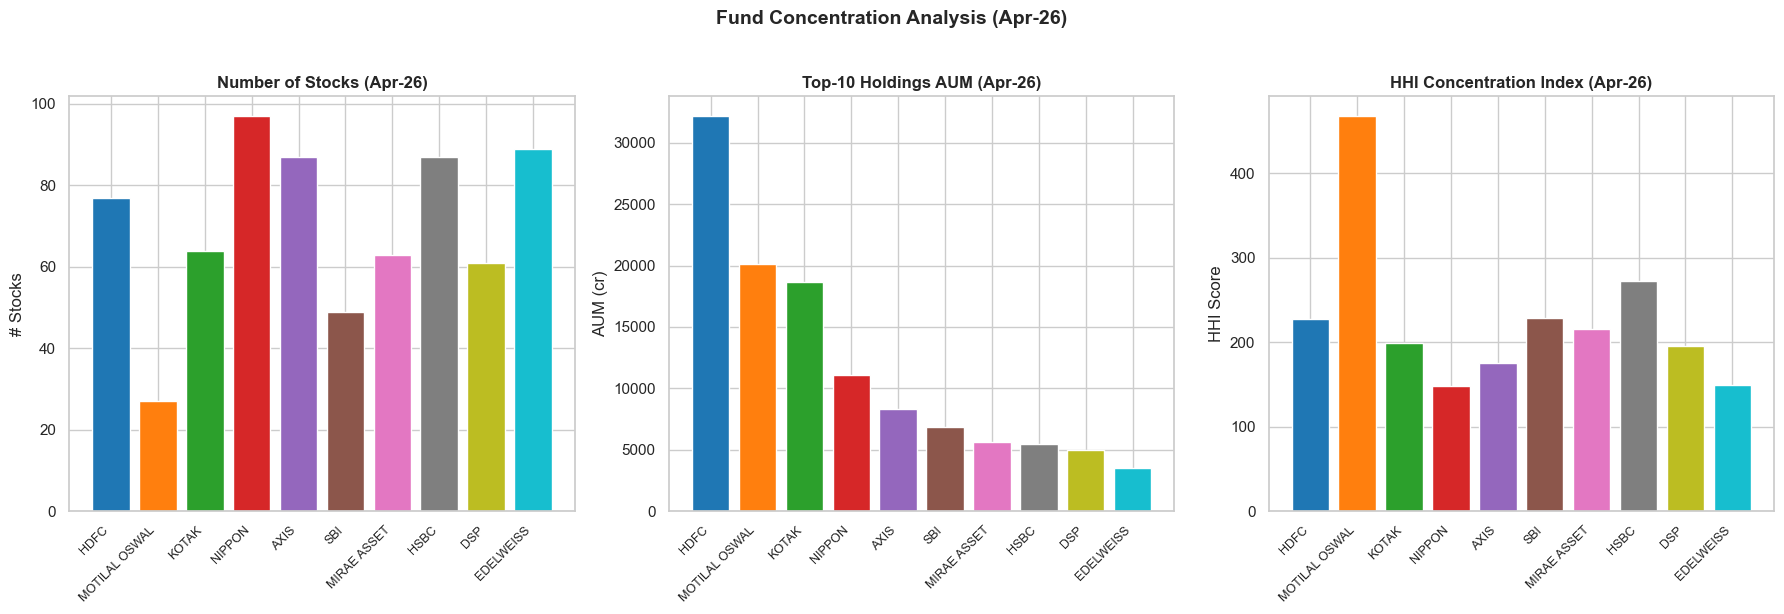

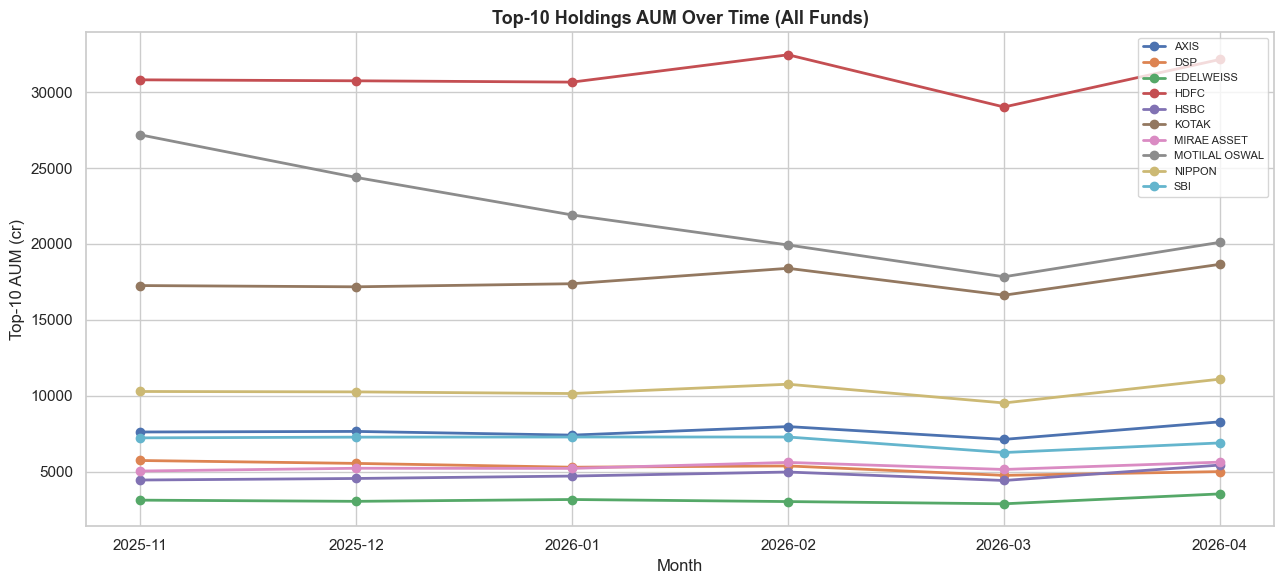

In [10]:
conc_data = []

for fund in FUNDS:
    df = raw_data[fund]
    
    for month in MONTHS_ORDER:
        if month not in df.columns:
            continue
        col = df[month].dropna()
        col = col[col > 0]
        
        if col.empty:
            continue
        
        total_alloc = col.sum()
        top10_alloc = col.nlargest(10).sum()
        n_stocks = len(col)
    
        
        # HHI — Herfindahl-Hirschman Index (concentration)
        weights = col / total_alloc
        hhi = (weights ** 2).sum() * 10000  # scale to 0-10000
        
        conc_data.append({
            'Fund': fund, 'Month': month,
            'No. of Stocks': n_stocks,
            'Top-10 AUM (cr)': round(top10_alloc, 2),
            'Total AUM': round(total_alloc, 2),
            'HHI (Concentration)': round(hhi, 1)
        })

conc_df = pd.DataFrame(conc_data)

# Apr-26 snapshot
conc_apr = conc_df[conc_df['Month'] == END_MONTH].sort_values('Top-10 AUM (cr)', ascending=False).reset_index(drop=True)
print('🔍 Concentration Analysis — Apr-26 Snapshot')
print('   HHI: Higher = More Concentrated | Lower = More Diversified')
display(conc_apr)

# Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1: No. of Stocks
axes[0].bar(conc_apr['Fund'], conc_apr['No. of Stocks'], color=sns.color_palette('tab10', len(conc_apr)))
axes[0].set_title('Number of Stocks (Apr-26)', fontweight='bold')
axes[0].set_xticklabels(conc_apr['Fund'], rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('# Stocks')

# Chart 2: Top-10 AUM (cr)
axes[1].bar(conc_apr['Fund'], conc_apr['Top-10 AUM (cr)'], color=sns.color_palette('tab10', len(conc_apr)))
axes[1].set_title('Top-10 Holdings AUM (Apr-26)', fontweight='bold')
axes[1].set_xticklabels(conc_apr['Fund'], rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('AUM (cr)')

# Chart 3: HHI
axes[2].bar(conc_apr['Fund'], conc_apr['HHI (Concentration)'], color=sns.color_palette('tab10', len(conc_apr)))
axes[2].set_title('HHI Concentration Index (Apr-26)', fontweight='bold')
axes[2].set_xticklabels(conc_apr['Fund'], rotation=45, ha='right', fontsize=9)
axes[2].set_ylabel('HHI Score')

plt.suptitle('Fund Concentration Analysis (Apr-26)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Monthly trend: Top-10 Allocation over time
conc_pivot = conc_df.pivot(index='Fund', columns='Month', values='Top-10 AUM (cr)')
conc_pivot = conc_pivot.reindex(columns=MONTHS_ORDER)

fig, ax = plt.subplots(figsize=(13, 6))
for fund in conc_pivot.index:
    ax.plot(MONTHS_ORDER, conc_pivot.loc[fund], marker='o', label=fund, linewidth=2)
ax.set_title('Top-10 Holdings AUM Over Time (All Funds)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Top-10 AUM (cr)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

---
## Analysis 6 — Net Buy / Net Sell by Fund
**Question:** Which stocks did each fund increase or reduce over Nov-25 to Apr-26?

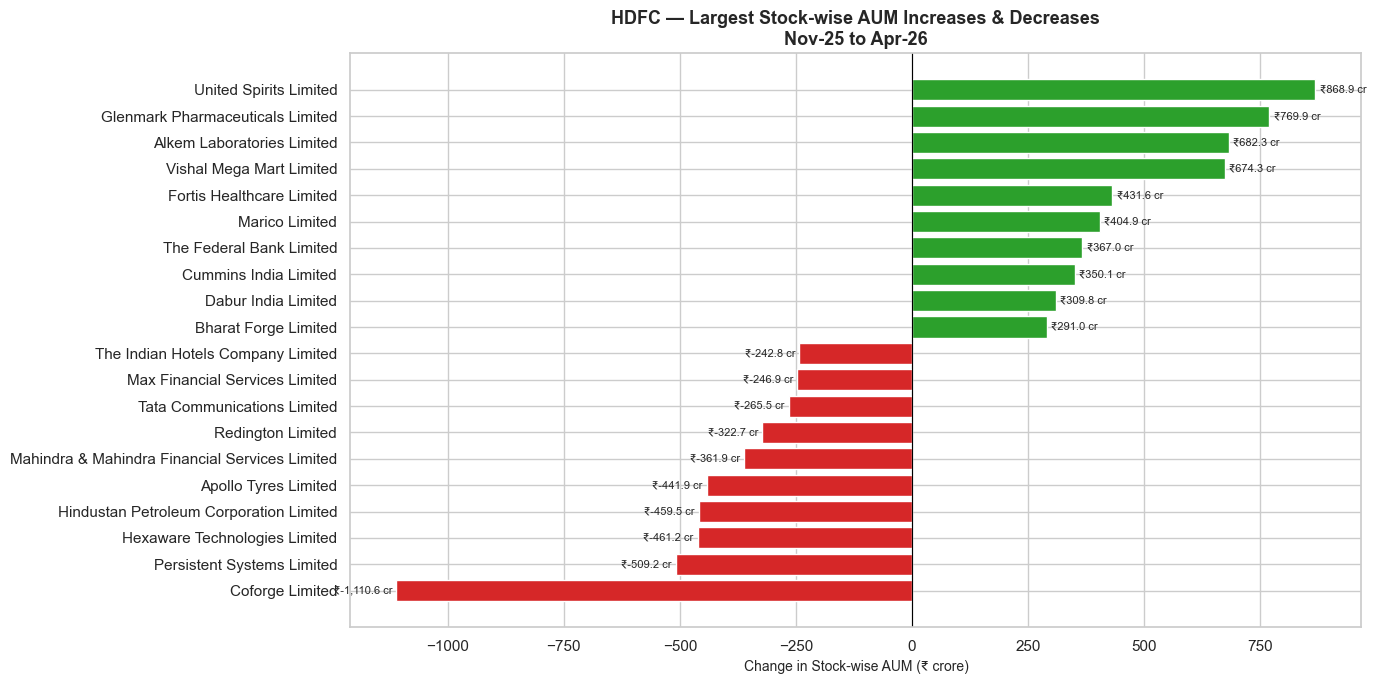

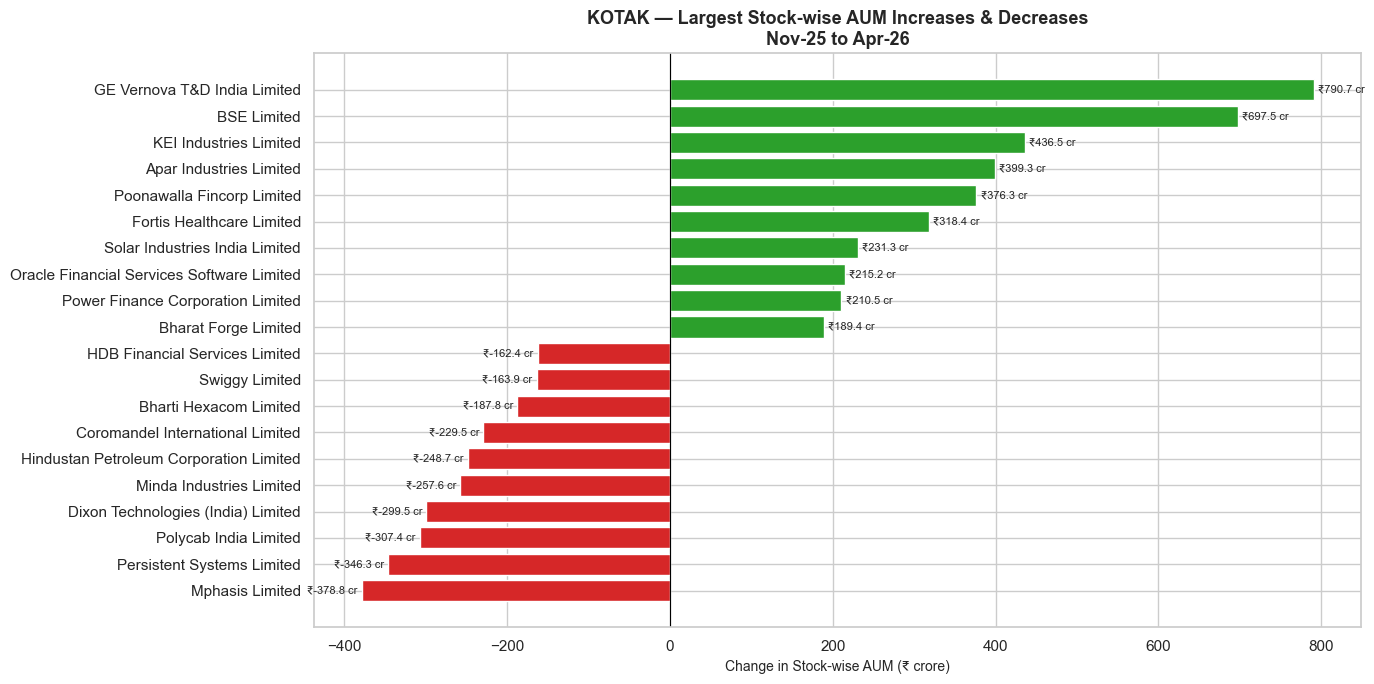

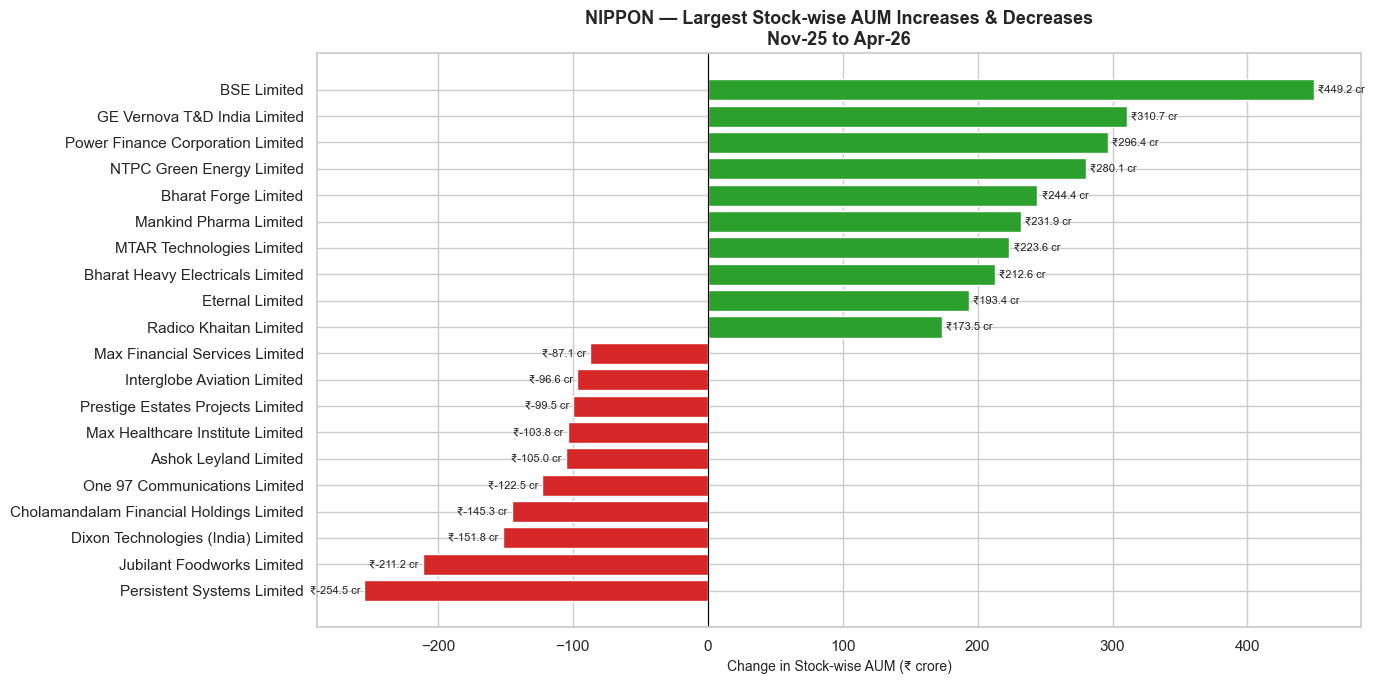

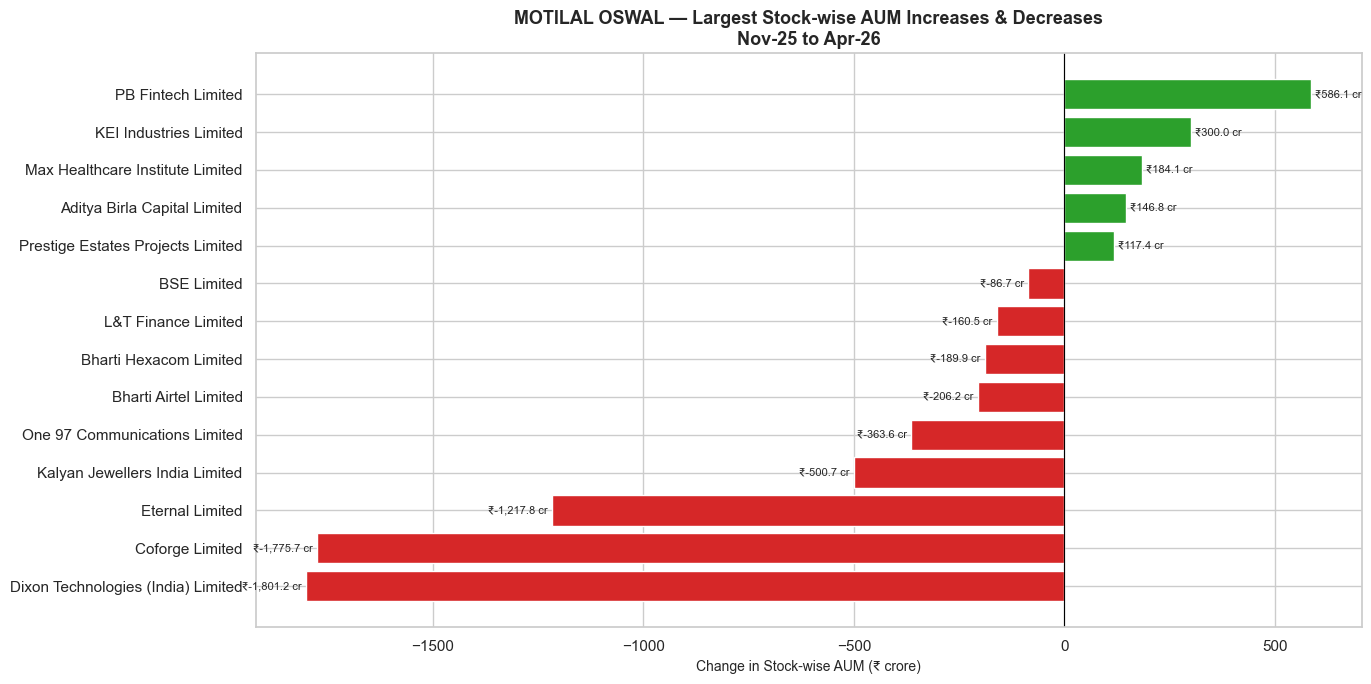

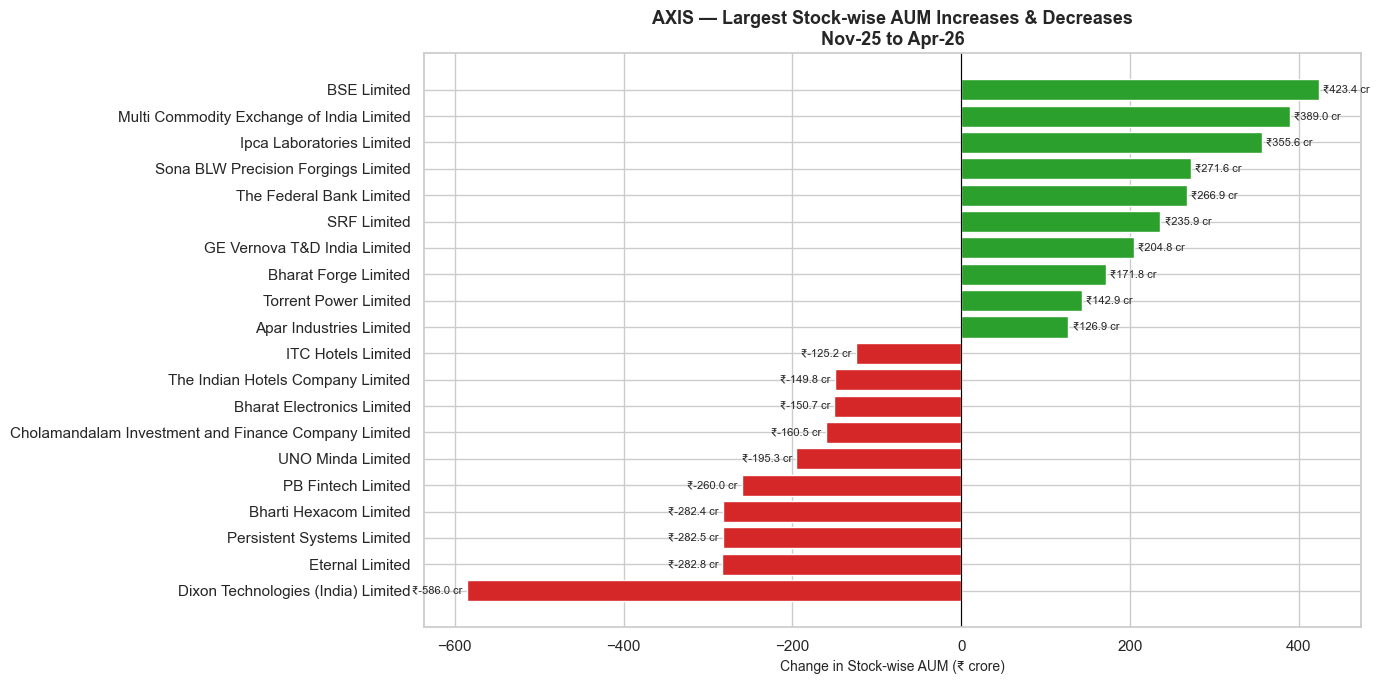

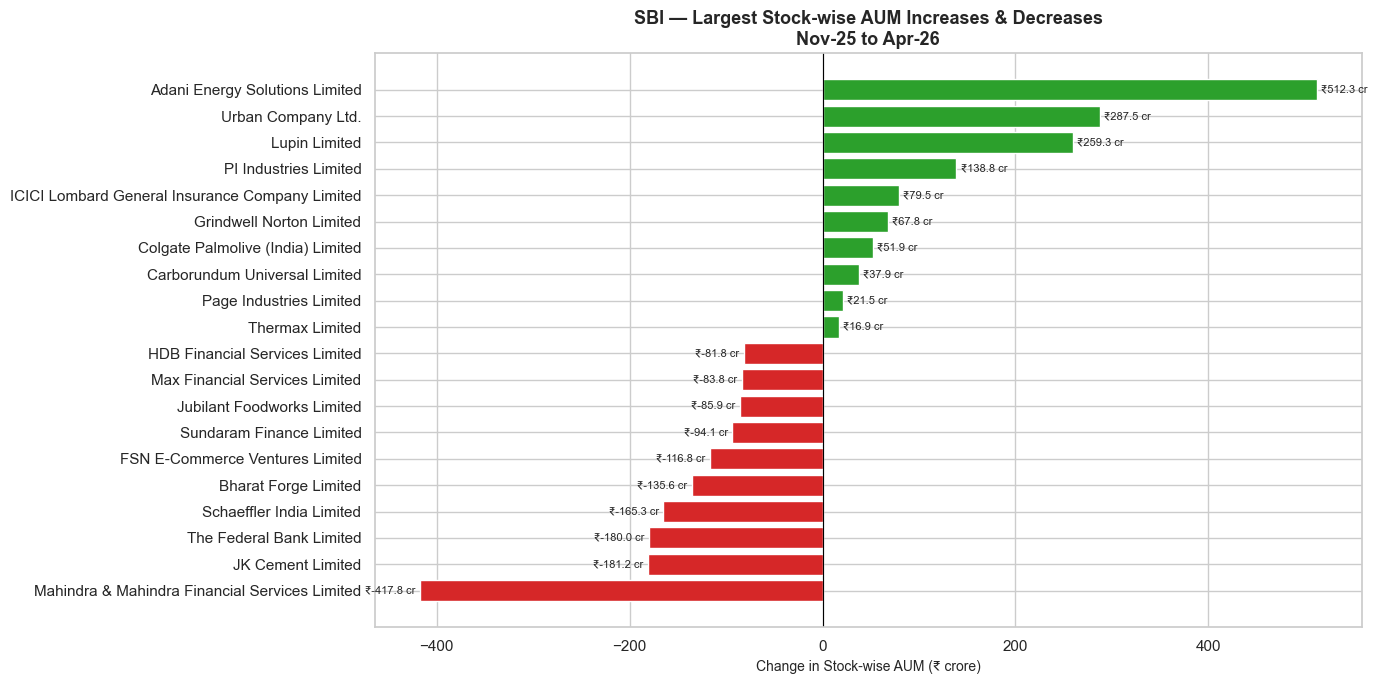

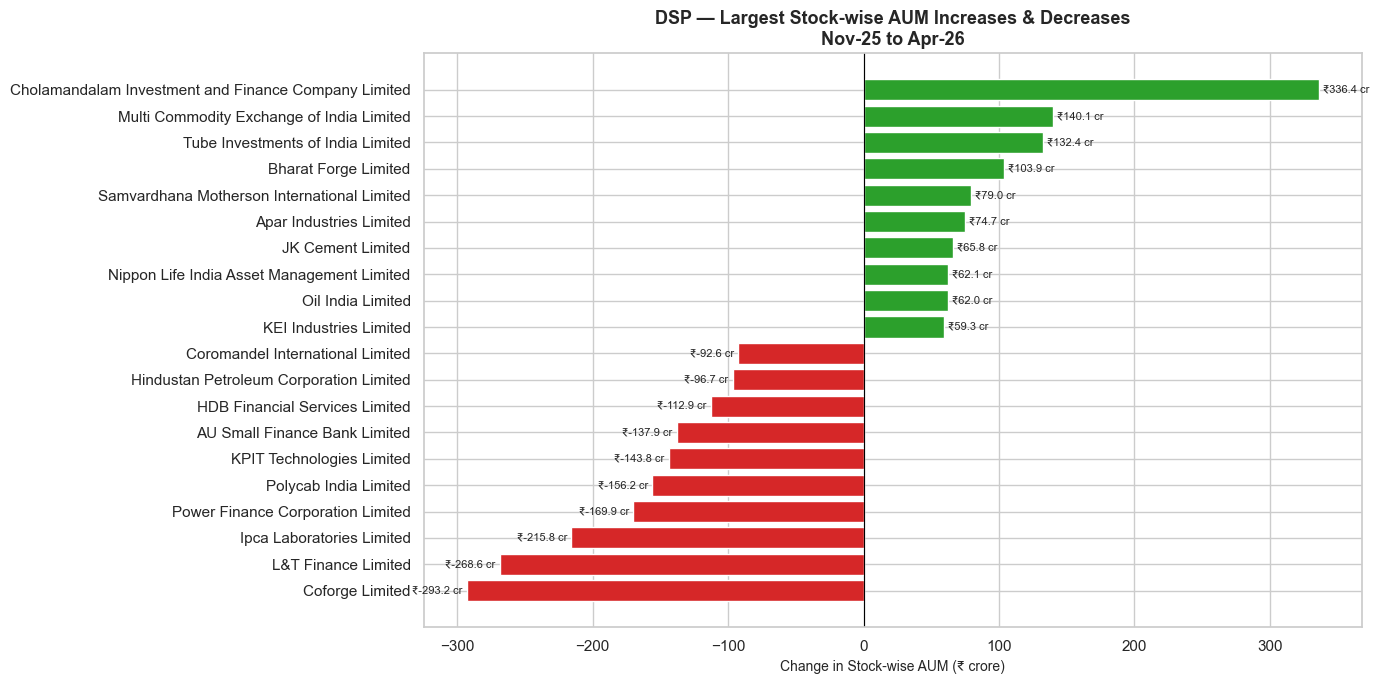

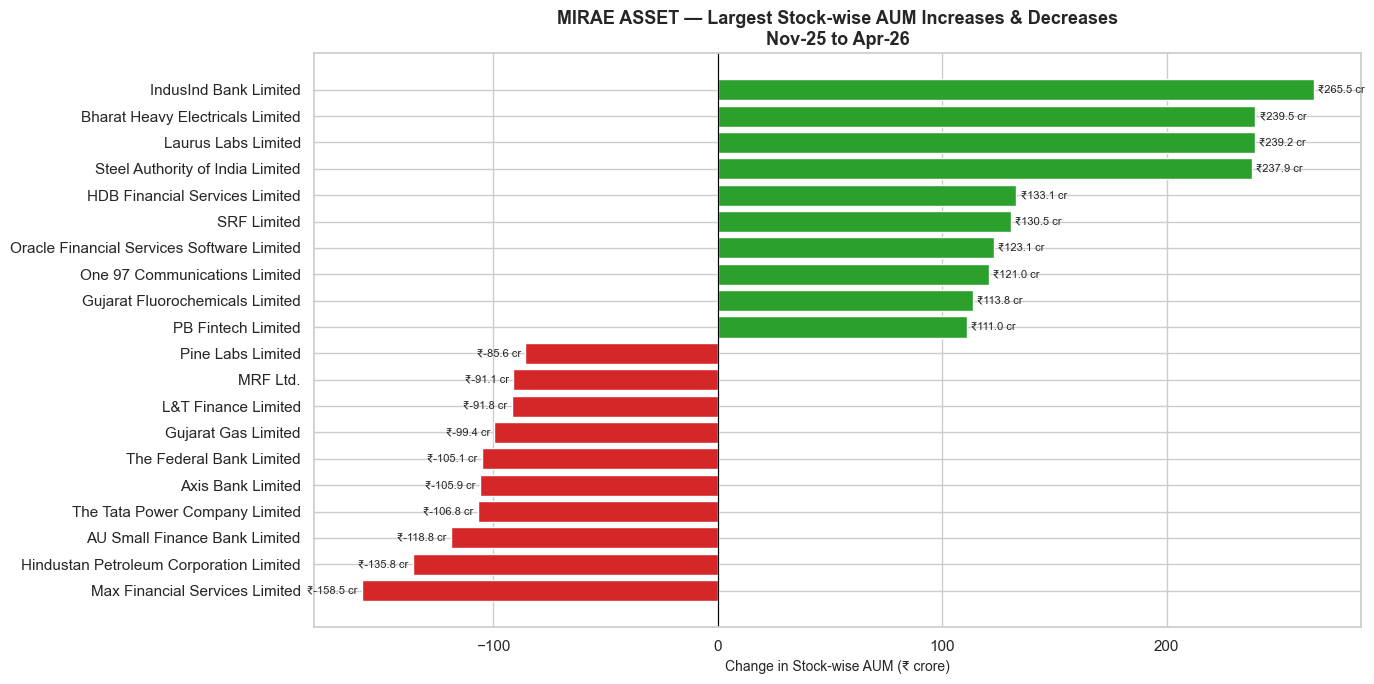

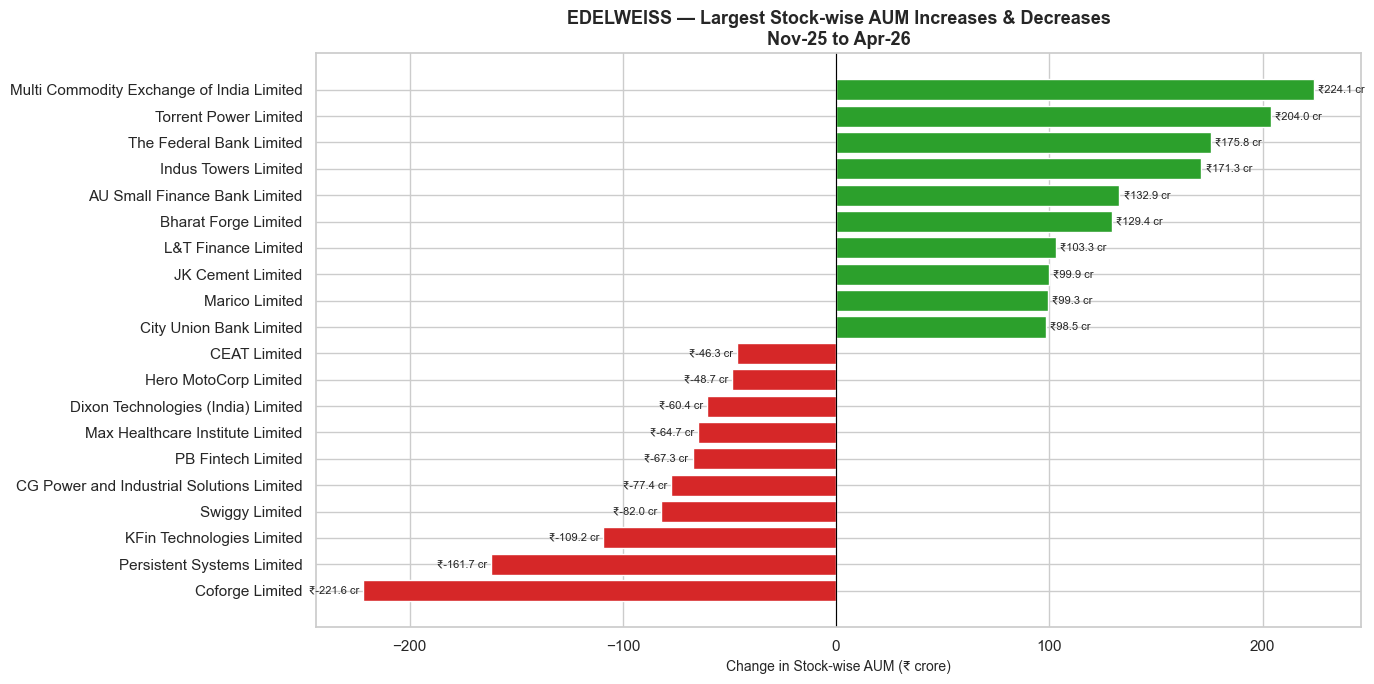

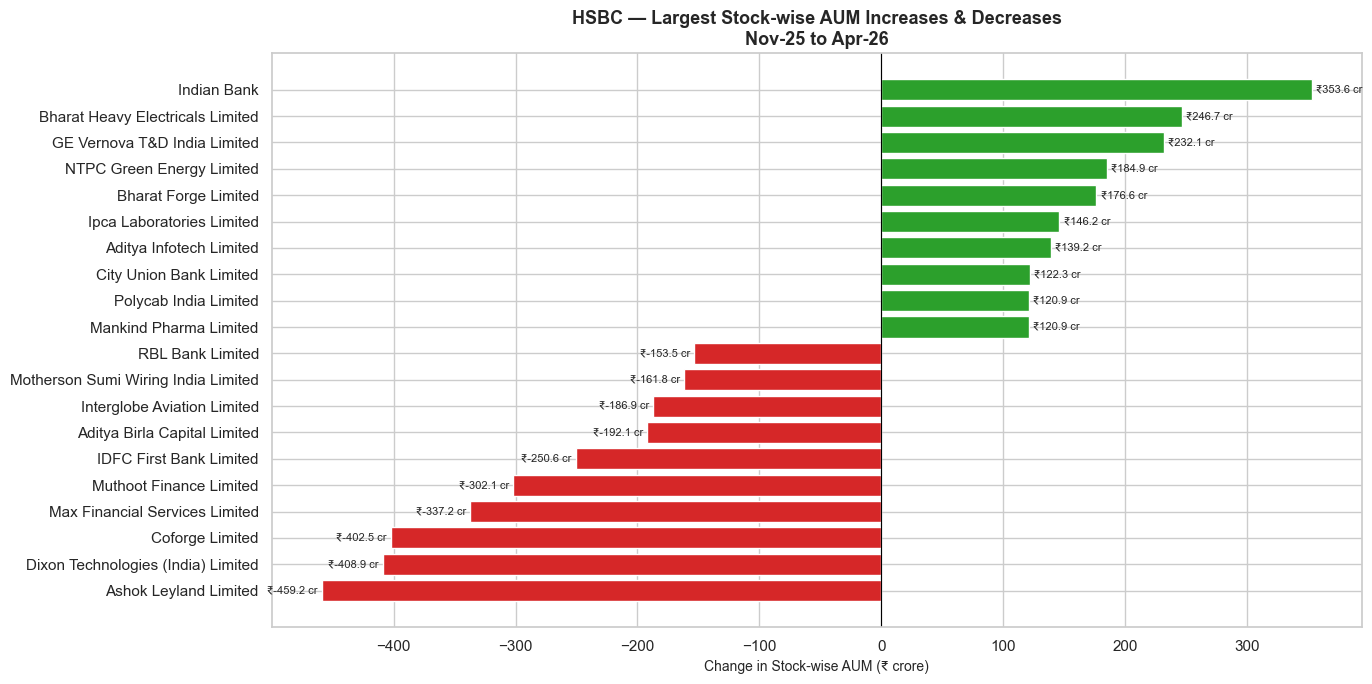

In [11]:
START_MONTH = '2025-11'
END_MONTH = '2026-04'

for fund, df in raw_data.items():
    if START_MONTH not in df.columns or END_MONTH not in df.columns:
        print(f'⚠️ Skipping {fund} — missing start or end month')
        continue
    
    # Since values are stock-wise AUM in ₹ crore
    change = df[END_MONTH] - df[START_MONTH]
    change = change.dropna()
    
    if change.empty:
        print(f'⚠️ Skipping {fund} — no valid stock-level AUM change data')
        continue
    
    # Top 10 increase and decrease in stock-wise AUM
    buys = change.nlargest(10)
    sells = change.nsmallest(10)
    
    combined = pd.concat([buys, sells])
    combined = combined[~combined.index.duplicated(keep='first')]
    combined = combined.sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    colors = ['#d62728' if v < 0 else '#2ca02c' for v in combined.values]
    
    bars = ax.barh(combined.index, combined.values, color=colors)
    
    ax.axvline(0, color='black', linewidth=0.8)
    
    ax.bar_label(
        bars,
        labels=[f'₹{v:,.1f} cr' for v in combined.values],
        padding=3,
        fontsize=8
    )
    
    ax.set_title(
        f'{fund} — Largest Stock-wise AUM Increases & Decreases\nNov-25 to Apr-26',
        fontsize=13,
        fontweight='bold'
    )
    
    ax.set_xlabel('Change in Stock-wise AUM (₹ crore)', fontsize=10)
    
    plt.subplots_adjust(left=0.35, right=0.95)
    plt.tight_layout()
    plt.show()

---
## Analysis 7 — Buy-Month Count
**Question:** Out of 5 month-to-month changes, how many months did AUM increase for each stock?

### Stock-wise AUM change = fund buying/selling + stock price movement ###
### AUM Increase Months ≠ Buy Months ###
### AUM Decrease Months ≠ Sell Months ###

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

aum_month_data = []

for fund, df in raw_data.items():

    df = df.replace("-", np.nan).copy()

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # If same stock appears more than once, combine stock-wise AUM
    df = df.groupby(df.index).sum(numeric_only=True)

    months = [m for m in MONTHS_ORDER if m in df.columns]

    if len(months) < 2:
        print(f"⚠️ Skipping {fund} — less than 2 months available")
        continue

    for stock in df.index:
        series = df.loc[stock, months]
        series = pd.to_numeric(series, errors="coerce")
        series = series.dropna()

        if len(series) < 2:
            continue

        month_changes = series.diff().dropna()

        increase_months = int((month_changes > 0).sum())
        decrease_months = int((month_changes < 0).sum())
        no_change_months = int((month_changes == 0).sum())

        start_aum = series.iloc[0]
        end_aum = series.iloc[-1]
        net_change = end_aum - start_aum

        aum_month_data.append({
            "Fund": fund,
            "Stock": stock,
            "AUM Increase Months": increase_months,
            "AUM Decrease Months": decrease_months,
            "No Change Months": no_change_months,
            "Total Periods": len(month_changes),
            "Net AUM Change (₹ Cr)": round(net_change, 2),
            "Start AUM (₹ Cr)": round(start_aum, 2),
            "End AUM (₹ Cr)": round(end_aum, 2)
        })

aum_month_df = pd.DataFrame(aum_month_data)

aum_agg = aum_month_df.groupby("Stock").agg(
    Funds_Tracked=("Fund", "count"),
    Total_AUM_Increase_Months=("AUM Increase Months", "sum"),
    Total_AUM_Decrease_Months=("AUM Decrease Months", "sum"),
    Total_No_Change_Months=("No Change Months", "sum"),
    Total_Periods=("Total Periods", "sum"),
    Total_Net_AUM_Change_Cr=("Net AUM Change (₹ Cr)", "sum"),
    Avg_Net_AUM_Change_Cr=("Net AUM Change (₹ Cr)", "mean")
).round(2).reset_index()

# Stocks tracked by at least 5 funds
aum_agg = aum_agg[aum_agg["Funds_Tracked"] >= 5]

# Share of months where AUM increased/decreased
aum_agg["AUM_Increase_Ratio"] = (
    aum_agg["Total_AUM_Increase_Months"] / aum_agg["Total_Periods"]
).round(2)

aum_agg["AUM_Decrease_Ratio"] = (
    aum_agg["Total_AUM_Decrease_Months"] / aum_agg["Total_Periods"]
).round(2)

aum_agg = aum_agg.sort_values(
    ["Total_AUM_Increase_Months", "Total_Net_AUM_Change_Cr"],
    ascending=False
)

print("📈 Total AUM Increase-Month Count — Stocks held by ≥5 Funds")
display(aum_agg.head(27).reset_index(drop=True))

📈 Total AUM Increase-Month Count — Stocks held by ≥5 Funds


,Stock,Funds_Tracked,Total_AUM_Increase_Months,Total_AUM_Decrease_Months,Total_No_Change_Months,Total_Periods,Total_Net_AUM_Change_Cr,Avg_Net_AUM_Change_Cr,AUM_Increase_Ratio,AUM_Decrease_Ratio
0,The Federal Bank Limited,9,35,9,1,45,998.35,110.93,0.78,0.20
1,Bharat Forge Limited,9,27,16,2,45,1253.92,139.32,0.60,0.36
2,Hindustan Petroleum Corporation Limited,8,22,16,2,40,-1338.62,-167.33,0.55,0.40
3,Multi Commodity Exchange of India Limited,8,21,12,7,40,3182.61,397.83,0.52,0.30
4,GE Vernova T&D India Limited,6,21,7,2,30,1626.48,271.08,0.70,0.23
5,Lupin Limited,6,21,5,4,30,646.85,107.81,0.70,0.17
6,BSE Limited,8,19,15,6,40,1530.15,191.27,0.48,0.38
7,PB Fintech Limited,7,19,14,2,35,706.87,100.98,0.54,0.40
8,AU Small Finance Bank Limited,8,19,16,5,40,695.89,86.99,0.48,0.40
9,JK Cement Limited,7,19,15,1,35,-177.70,-25.39,0.54,0.43


---
## Analysis 8 — AUM Accumulation Score
**Question:** Which stocks show consistent accumulation? Score = Buy Months − Sell Months

In [13]:
## Analysis 8 — AUM Accumulation Score
# Question: Which stocks show consistent increase in stock-wise AUM?
# Score = Total AUM Increase Months − Total AUM Decrease Months

accumulation_df = aum_month_df.groupby("Stock").agg(
    Funds_Tracked=("Fund", "count"),
    Total_AUM_Increase_Months=("AUM Increase Months", "sum"),
    Total_AUM_Decrease_Months=("AUM Decrease Months", "sum"),
    Total_No_Change_Months=("No Change Months", "sum"),
    Total_Periods=("Total Periods", "sum"),
    Total_Net_AUM_Change_Cr=("Net AUM Change (₹ Cr)", "sum"),
    Avg_Net_AUM_Change_Cr=("Net AUM Change (₹ Cr)", "mean")
).round(2).reset_index()

# Stocks held by at least 5 funds
accumulation_df = accumulation_df[accumulation_df["Funds_Tracked"] >= 5].copy()

# AUM Accumulation Score
accumulation_df["AUM_Accumulation_Score"] = (
    accumulation_df["Total_AUM_Increase_Months"] 
    - accumulation_df["Total_AUM_Decrease_Months"]
)

# Optional: normalized score between -1 and +1
accumulation_df["AUM_Accumulation_Ratio"] = (
    accumulation_df["AUM_Accumulation_Score"] 
    / accumulation_df["Total_Periods"]
).round(2)

# Sort by strongest accumulation
accumulation_df = accumulation_df.sort_values(
    ["AUM_Accumulation_Score", "Total_Net_AUM_Change_Cr"],
    ascending=False
)

print("📊 Analysis 5 — AUM Accumulation Score")
print("Score = Total AUM Increase Months − Total AUM Decrease Months")
display(accumulation_df.head(10).reset_index(drop=True))

📊 Analysis 5 — AUM Accumulation Score
Score = Total AUM Increase Months − Total AUM Decrease Months


,Stock,Funds_Tracked,Total_AUM_Increase_Months,Total_AUM_Decrease_Months,Total_No_Change_Months,Total_Periods,Total_Net_AUM_Change_Cr,Avg_Net_AUM_Change_Cr,AUM_Accumulation_Score,AUM_Accumulation_Ratio
0,The Federal Bank Limited,9,35,9,1,45,998.35,110.93,26,0.58
1,Lupin Limited,6,21,5,4,30,646.85,107.81,16,0.53
2,GE Vernova T&D India Limited,6,21,7,2,30,1626.48,271.08,14,0.47
3,Bharat Forge Limited,9,27,16,2,45,1253.92,139.32,11,0.24
4,Multi Commodity Exchange of India Limited,8,21,12,7,40,3182.61,397.83,9,0.22
5,Jindal Steel Limited,5,15,6,4,25,388.27,77.65,9,0.36
6,ICICI Prudential Asset Management Company Limited,5,14,6,5,25,1166.36,233.27,8,0.32
7,Mankind Pharma Limited,5,14,7,4,25,615.68,123.14,7,0.28
8,Oil India Limited,6,13,6,11,30,-89.00,-14.83,7,0.23
9,Indus Towers Limited,6,16,10,4,30,250.39,41.73,6,0.20


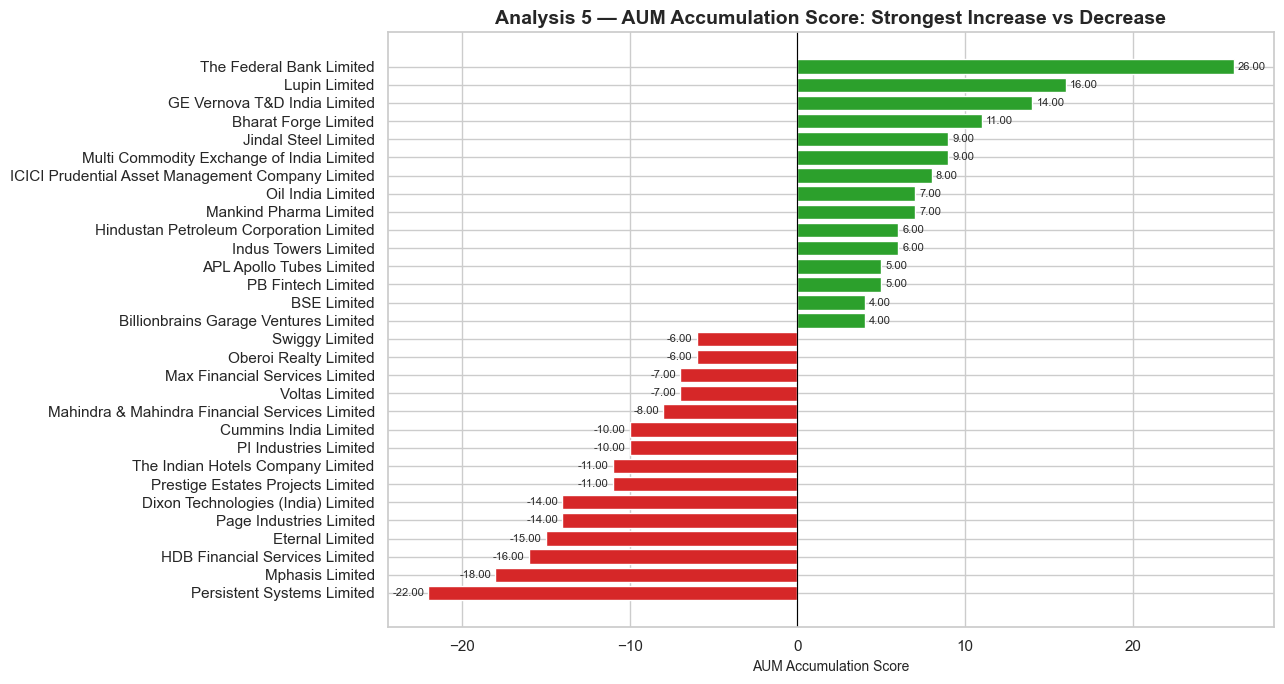

In [15]:
# Graph — Highest and Lowest AUM Accumulation Ratio

top_positive = accumulation_df.nlargest(15, "AUM_Accumulation_Score")
top_negative = accumulation_df.nsmallest(15, "AUM_Accumulation_Score")

ratio_combined = pd.concat([top_positive, top_negative])
ratio_combined = ratio_combined.drop_duplicates(subset=["Stock"])
ratio_combined = ratio_combined.sort_values("AUM_Accumulation_Score", ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))

colors = [
    "#2ca02c" if v > 0 else "#d62728"
    for v in ratio_combined["AUM_Accumulation_Score"]
]

bars = ax.barh(
    ratio_combined["Stock"],
    ratio_combined["AUM_Accumulation_Score"],
    color=colors
)

ax.axvline(0, color="black", linewidth=0.8)

ax.bar_label(
    bars,
    labels=[f'{v:.2f}' for v in ratio_combined["AUM_Accumulation_Score"]],
    padding=3,
    fontsize=8
)

ax.set_title(
    "Analysis 5 — AUM Accumulation Score: Strongest Increase vs Decrease",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "AUM Accumulation Score",
    fontsize=10
)

plt.subplots_adjust(left=0.35, right=0.95)
plt.tight_layout()
plt.show()

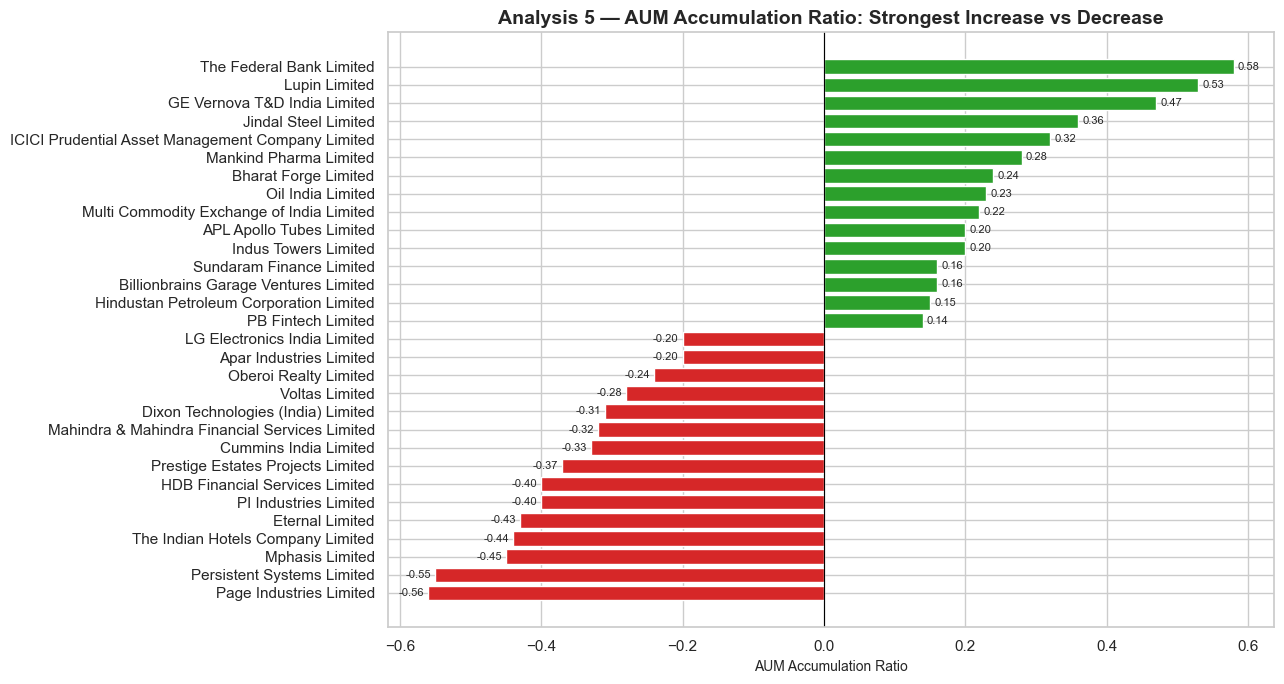

In [16]:
# Graph — Highest and Lowest AUM Accumulation Ratio

top_positive = accumulation_df.nlargest(15, "AUM_Accumulation_Ratio")
top_negative = accumulation_df.nsmallest(15, "AUM_Accumulation_Ratio")

ratio_combined = pd.concat([top_positive, top_negative])
ratio_combined = ratio_combined.drop_duplicates(subset=["Stock"])
ratio_combined = ratio_combined.sort_values("AUM_Accumulation_Ratio", ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))

colors = [
    "#2ca02c" if v > 0 else "#d62728"
    for v in ratio_combined["AUM_Accumulation_Ratio"]
]

bars = ax.barh(
    ratio_combined["Stock"],
    ratio_combined["AUM_Accumulation_Ratio"],
    color=colors
)

ax.axvline(0, color="black", linewidth=0.8)

ax.bar_label(
    bars,
    labels=[f'{v:.2f}' for v in ratio_combined["AUM_Accumulation_Ratio"]],
    padding=3,
    fontsize=8
)

ax.set_title(
    "Analysis 5 — AUM Accumulation Ratio: Strongest Increase vs Decrease",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "AUM Accumulation Ratio",
    fontsize=10
)

plt.subplots_adjust(left=0.35, right=0.95)
plt.tight_layout()
plt.show()

In [17]:
import yfinance as yf
import pandas as pd
import numpy as np

# 30 stocks from Mid-cap AUM Accumulation Score chart
stocks_30 = {
    # Strongest Accumulators
    "The Federal Bank Limited": "FEDERALBNK.NS",
    "Lupin Limited": "LUPIN.NS",
    "GE Vernova T&D India Limited": "GVT&D.NS",
    "Bharat Forge Limited": "BHARATFORG.NS",
    "Jindal Steel Limited": "JINDALSTEL.NS",
    "Multi Commodity Exchange of India Limited": "MCX.NS",
    "ICICI Prudential Asset Management Company Limited": "ICICIAMC.NS",
    "Oil India Limited": "OIL.NS",
    "Mankind Pharma Limited": "MANKIND.NS",
    "Hindustan Petroleum Corporation Limited": "HINDPETRO.NS",
    "Indus Towers Limited": "INDUSTOWER.NS",
    "APL Apollo Tubes Limited": "APLAPOLLO.NS",
    "PB Fintech Limited": "POLICYBZR.NS",
    "BSE Limited": "BSE.NS",
    "Billionbrains Garage Ventures Limited": "GROWW.NS",

    # Strongest Distributors
    "Swiggy Limited": "SWIGGY.NS",
    "Oberoi Realty Limited": "OBEROIRLTY.NS",
    "Max Financial Services Limited": "MFSL.NS",
    "Voltas Limited": "VOLTAS.NS",
    "Mahindra & Mahindra Financial Services Limited": "M&MFIN.NS",
    "Cummins India Limited": "CUMMINSIND.NS",
    "PI Industries Limited": "PIIND.NS",
    "The Indian Hotels Company Limited": "INDHOTEL.NS",
    "Prestige Estates Projects Limited": "PRESTIGE.NS",
    "Dixon Technologies (India) Limited": "DIXON.NS",
    "Page Industries Limited": "PAGEIND.NS",
    "Eternal Limited": "ETERNAL.NS",
    "HDB Financial Services Limited": "HDBFS.NS",
    "Mphasis Limited": "MPHASIS.NS",
    "Persistent Systems Limited": "PERSISTENT.NS"
}

# 5-month return period
start_date = "2025-11-30"
end_date = "2026-04-30"

# Download buffer
start_download = "2025-11-20"
end_download = "2026-05-05"


def get_nearest_price(price_series, target_date):
    """
    Use nearest available trading price on or before target date.
    """
    target_date = pd.to_datetime(target_date)
    available = price_series[price_series.index <= target_date]

    if available.empty:
        return np.nan, None

    return available.iloc[-1], available.index[-1].date()


five_month_results = []

for stock_name, ticker in stocks_30.items():
    try:
        data = yf.download(
            ticker,
            start=start_download,
            end=end_download,
            auto_adjust=True,
            progress=False,
            multi_level_index=False
        )

        if data.empty:
            five_month_results.append({
                "Stock": stock_name,
                "Ticker": ticker,
                "Error": "No data found"
            })
            continue

        price = data["Close"].dropna()

        start_price, actual_start_date = get_nearest_price(price, start_date)
        end_price, actual_end_date = get_nearest_price(price, end_date)

        if pd.isna(start_price) or pd.isna(end_price):
            five_m_return = np.nan
        else:
            five_m_return = ((end_price / start_price) - 1) * 100

        five_month_results.append({
            "Stock": stock_name,
            "Ticker": ticker,
            "5M Start Date": actual_start_date,
            "5M Start Price": round(float(start_price), 2),
            "5M End Date": actual_end_date,
            "5M End Price": round(float(end_price), 2),
            "5M Return (%)": round(float(five_m_return), 2)
        })

    except Exception as e:
        five_month_results.append({
            "Stock": stock_name,
            "Ticker": ticker,
            "Error": str(e)
        })

five_m_return_df = pd.DataFrame(five_month_results)

display(five_m_return_df)

five_m_return_df.to_csv(
    "midcap_30_stocks_5m_return.csv",
    index=False
)

,Stock,Ticker,5M Start Date,5M Start Price,5M End Date,5M End Price,5M Return (%)
0,The Federal Bank Limited,FEDERALBNK.NS,2025-11-28,257.92,2026-04-30,286.95,11.26
1,Lupin Limited,LUPIN.NS,2025-11-28,2082.20,2026-04-30,2305.20,10.71
2,GE Vernova T&D India Limited,GVT&D.NS,2025-11-28,2881.40,2026-04-30,4466.20,55.00
3,Bharat Forge Limited,BHARATFORG.NS,2025-11-28,1432.16,2026-04-30,1881.60,31.38
4,Jindal Steel Limited,JINDALSTEL.NS,2025-11-28,1044.40,2026-04-30,1223.10,17.11
5,Multi Commodity Exchange of India Limited,MCX.NS,2025-11-28,2014.70,2026-04-30,2971.50,47.49
6,ICICI Prudential Asset Management Company Limited,ICICIAMC.NS,None,NaN,2026-04-30,3290.20,NaN
7,Oil India Limited,OIL.NS,2025-11-28,406.98,2026-04-30,490.80,20.60
8,Mankind Pharma Limited,MANKIND.NS,2025-11-28,2251.00,2026-04-30,2246.70,-0.19
9,Hindustan Petroleum Corporation Limited,HINDPETRO.NS,2025-11-28,457.50,2026-04-30,374.55,-18.13


In [19]:
# Manual correction for ICICI Prudential AMC
mask = five_m_return_df["Stock"] == "ICICI Prudential Asset Management Company Limited"

five_m_return_df.loc[mask, "5M Start Date"] = pd.to_datetime("2025-12-19").date()
five_m_return_df.loc[mask, "5M Start Price"] = 2585.90

# Recalculate 5M return using manual start price and existing end price
five_m_return_df.loc[mask, "5M Return (%)"] = (
    (
        five_m_return_df.loc[mask, "5M End Price"].astype(float)
        / five_m_return_df.loc[mask, "5M Start Price"].astype(float)
    ) - 1
) * 100

five_m_return_df.loc[mask, "5M Return (%)"] = five_m_return_df.loc[
    mask, "5M Return (%)"
].round(2)

# Optional note column
five_m_return_df.loc[mask, "Return Note"] = "Manual start date: 19-Dec-2025"

display(five_m_return_df[mask])

,Stock,Ticker,5M Start Date,5M Start Price,5M End Date,5M End Price,5M Return (%),Return Note
6,ICICI Prudential Asset Management Company Limited,ICICIAMC.NS,2025-12-19,2585.9,2026-04-30,3290.2,27.24,Manual start date: 19-Dec-2025


In [20]:
display(five_m_return_df)

,Stock,Ticker,5M Start Date,5M Start Price,5M End Date,5M End Price,5M Return (%),Return Note
0,The Federal Bank Limited,FEDERALBNK.NS,2025-11-28,257.92,2026-04-30,286.95,11.26,NaN
1,Lupin Limited,LUPIN.NS,2025-11-28,2082.20,2026-04-30,2305.20,10.71,NaN
2,GE Vernova T&D India Limited,GVT&D.NS,2025-11-28,2881.40,2026-04-30,4466.20,55.00,NaN
3,Bharat Forge Limited,BHARATFORG.NS,2025-11-28,1432.16,2026-04-30,1881.60,31.38,NaN
4,Jindal Steel Limited,JINDALSTEL.NS,2025-11-28,1044.40,2026-04-30,1223.10,17.11,NaN
5,Multi Commodity Exchange of India Limited,MCX.NS,2025-11-28,2014.70,2026-04-30,2971.50,47.49,NaN
6,ICICI Prudential Asset Management Company Limited,ICICIAMC.NS,2025-12-19,2585.90,2026-04-30,3290.20,27.24,Manual start date: 19-Dec-2025
7,Oil India Limited,OIL.NS,2025-11-28,406.98,2026-04-30,490.80,20.60,NaN
8,Mankind Pharma Limited,MANKIND.NS,2025-11-28,2251.00,2026-04-30,2246.70,-0.19,NaN
9,Hindustan Petroleum Corporation Limited,HINDPETRO.NS,2025-11-28,457.50,2026-04-30,374.55,-18.13,NaN


In [21]:
# --- Final 3-column table: Stock | 5M Return | AUM Accumulation Score ---

# 1. Prepare 5M return table
return_5m_table = five_m_return_df[
    ["Stock", "5M Return (%)"]
].copy()

# 2. Prepare AUM accumulation score table
acc_score_table = accumulation_df[
    ["Stock", "AUM_Accumulation_Score"]
].copy()


# 3. Clean stock names for safe matching
def clean_stock_name(x):
    x = str(x).lower()
    x = x.replace("limited", "")
    x = x.replace("ltd", "")
    x = x.replace(".", "")
    x = x.replace("&", "and")
    x = x.replace("-", " ")
    x = x.replace("(", "")
    x = x.replace(")", "")
    x = " ".join(x.split())
    return x


return_5m_table["Clean Stock"] = return_5m_table["Stock"].apply(clean_stock_name)
acc_score_table["Clean Stock"] = acc_score_table["Stock"].apply(clean_stock_name)


# 4. Merge 5M return with AUM accumulation score
final_30_5m_accumulation = return_5m_table.merge(
    acc_score_table[["Clean Stock", "AUM_Accumulation_Score"]],
    on="Clean Stock",
    how="left"
)


# 5. Keep only required 3 columns
final_30_5m_accumulation = final_30_5m_accumulation[
    [
        "Stock",
        "5M Return (%)",
        "AUM_Accumulation_Score"
    ]
].copy()


# 6. Sort by 5M return
final_30_5m_accumulation = final_30_5m_accumulation.sort_values(
    by="5M Return (%)",
    ascending=False
).reset_index(drop=True)


# 7. Display final table
display(final_30_5m_accumulation)


# 8. Save output
final_30_5m_accumulation.to_csv(
    "midcap_30_stocks_5m_return_aum_accumulation_score.csv",
    index=False
)

,Stock,5M Return (%),AUM_Accumulation_Score
0,GE Vernova T&D India Limited,55.00,14
1,Multi Commodity Exchange of India Limited,47.49,9
2,Billionbrains Garage Ventures Limited,35.32,4
3,Bharat Forge Limited,31.38,11
4,ICICI Prudential Asset Management Company Limited,27.24,8
5,BSE Limited,25.43,4
6,Oil India Limited,20.60,7
7,Cummins India Limited,18.11,-10
8,Jindal Steel Limited,17.11,9
9,The Federal Bank Limited,11.26,26


In [22]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Make copy
analysis_5m = final_30_5m_accumulation.copy()

# Convert to numeric
analysis_5m["5M Return (%)"] = pd.to_numeric(
    analysis_5m["5M Return (%)"], errors="coerce"
)

analysis_5m["AUM_Accumulation_Score"] = pd.to_numeric(
    analysis_5m["AUM_Accumulation_Score"], errors="coerce"
)

# Drop missing values
analysis_5m = analysis_5m.dropna(
    subset=["5M Return (%)", "AUM_Accumulation_Score"]
).copy()

display(analysis_5m)

,Stock,5M Return (%),AUM_Accumulation_Score
0,GE Vernova T&D India Limited,55.00,14
1,Multi Commodity Exchange of India Limited,47.49,9
2,Billionbrains Garage Ventures Limited,35.32,4
3,Bharat Forge Limited,31.38,11
4,ICICI Prudential Asset Management Company Limited,27.24,8
5,BSE Limited,25.43,4
6,Oil India Limited,20.60,7
7,Cummins India Limited,18.11,-10
8,Jindal Steel Limited,17.11,9
9,The Federal Bank Limited,11.26,26


In [24]:
x = analysis_5m["AUM_Accumulation_Score"]
y = analysis_5m["5M Return (%)"]

pearson_corr, pearson_p = pearsonr(x, y)
spearman_corr, spearman_p = spearmanr(x, y)

corr_5m_table = pd.DataFrame({
    "Method": ["Pearson Correlation", "Spearman Rank Correlation"],
    "Correlation": [round(pearson_corr, 4), round(spearman_corr, 8)],
    "P-value": [round(pearson_p, 4), round(spearman_p, 8)]
})

display(corr_5m_table)

,Method,Correlation,P-value
0,Pearson Correlation,0.677800,0.000000
1,Spearman Rank Correlation,0.704232,0.000014


In [25]:
X = analysis_5m[["AUM_Accumulation_Score"]]
Y = analysis_5m["5M Return (%)"]

X = sm.add_constant(X)

model_5m = sm.OLS(Y, X).fit()

print(model_5m.summary())

                            OLS Regression Results                            
Dep. Variable:          5M Return (%)   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     23.79
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           3.87e-05
Time:                        13:16:18   Log-Likelihood:                -125.67
No. Observations:                  30   AIC:                             255.3
Df Residuals:                      28   BIC:                             258.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      4

In [26]:
reg_5m_summary = pd.DataFrame({
    "Metric": [
        "Alpha / Intercept",
        "Beta: AUM Accumulation Score",
        "R-squared",
        "Adjusted R-squared",
        "P-value of Beta",
        "Observations"
    ],
    "Value": [
        round(model_5m.params["const"], 4),
        round(model_5m.params["AUM_Accumulation_Score"], 4),
        round(model_5m.rsquared, 4),
        round(model_5m.rsquared_adj, 4),
        round(model_5m.pvalues["AUM_Accumulation_Score"], 4),
        int(model_5m.nobs)
    ]
})

display(reg_5m_summary)

,Metric,Value
0,Alpha / Intercept,4.8393
1,Beta: AUM Accumulation Score,1.2684
2,R-squared,0.4594
3,Adjusted R-squared,0.4401
4,P-value of Beta,0.0000
5,Observations,30.0000


### The mid-cap analysis shows a strong positive and statistically significant relationship between AUM accumulation score and 5-month stock return. The Pearson correlation is 0.678, while the Spearman rank correlation is 0.704, suggesting that stocks with higher accumulation scores also tend to rank better in returns. The regression coefficient is 1.268, significant at the 1% level, and the model explains about 45.9% of the cross-sectional variation in 5-month returns. This supports the use of AUM accumulation score as a useful stock-selection signal in the mid-cap fund universe. ###

# "3M Analysis" #

In [27]:
import pandas as pd
import numpy as np

# Exact month columns in your raw_data
FOCUS_MONTHS = ["2026-01", "2026-02", "2026-03", "2026-04"]

aum_3m_data = []

for fund, df in raw_data.items():

    df = df.replace("-", np.nan).copy()

    # Convert all columns to numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Combine duplicate stock names if same stock appears more than once
    df = df.groupby(df.index).sum(numeric_only=True)

    # Keep only Jan-Apr columns
    months = [m for m in FOCUS_MONTHS if m in df.columns]

    print(f"{fund} available focus months:", months)

    if len(months) < 2:
        print(f"⚠️ Skipping {fund} — less than 2 required months available")
        continue

    for stock in df.index:

        series = df.loc[stock, months]
        series = pd.to_numeric(series, errors="coerce")

        # Month-wise changes
        feb_change = np.nan
        mar_change = np.nan
        apr_change = np.nan

        if pd.notna(series.get("2026-01")) and pd.notna(series.get("2026-02")):
            feb_change = series["2026-02"] - series["2026-01"]

        if pd.notna(series.get("2026-02")) and pd.notna(series.get("2026-03")):
            mar_change = series["2026-03"] - series["2026-02"]

        if pd.notna(series.get("2026-03")) and pd.notna(series.get("2026-04")):
            apr_change = series["2026-04"] - series["2026-03"]

        changes = pd.Series({
            "Feb Change": feb_change,
            "Mar Change": mar_change,
            "Apr Change": apr_change
        }).dropna()

        if len(changes) == 0:
            continue

        increase_months = int((changes > 0).sum())
        decrease_months = int((changes < 0).sum())
        no_change_months = int((changes == 0).sum())

        net_3m_change = changes.sum()

        aum_3m_data.append({
            "Fund": fund,
            "Stock": stock,

            "Jan 2026 AUM": round(series.get("2026-01", np.nan), 2),
            "Feb 2026 AUM": round(series.get("2026-02", np.nan), 2),
            "Mar 2026 AUM": round(series.get("2026-03", np.nan), 2),
            "Apr 2026 AUM": round(series.get("2026-04", np.nan), 2),

            "Feb Change (₹ Cr)": round(feb_change, 2) if pd.notna(feb_change) else np.nan,
            "Mar Change (₹ Cr)": round(mar_change, 2) if pd.notna(mar_change) else np.nan,
            "Apr Change (₹ Cr)": round(apr_change, 2) if pd.notna(apr_change) else np.nan,

            "3M Increase Months": increase_months,
            "3M Decrease Months": decrease_months,
            "3M No Change Months": no_change_months,
            "3M Total Periods": len(changes),
            "Net 3M AUM Change (₹ Cr)": round(net_3m_change, 2)
        })

aum_3m_df = pd.DataFrame(aum_3m_data)

print("Fund-stock level Feb-Mar-Apr AUM movement")
display(aum_3m_df.head())

HDFC available focus months: ['2026-01', '2026-02', '2026-03', '2026-04']
KOTAK available focus months: ['2026-01', '2026-02', '2026-03', '2026-04']
NIPPON available focus months: ['2026-01', '2026-02', '2026-03', '2026-04']
MOTILAL OSWAL available focus months: ['2026-01', '2026-02', '2026-03', '2026-04']
AXIS available focus months: ['2026-01', '2026-02', '2026-03', '2026-04']
SBI available focus months: ['2026-01', '2026-02', '2026-03', '2026-04']
DSP available focus months: ['2026-01', '2026-02', '2026-03', '2026-04']
MIRAE ASSET available focus months: ['2026-01', '2026-02', '2026-03', '2026-04']
EDELWEISS available focus months: ['2026-01', '2026-02', '2026-03', '2026-04']
HSBC available focus months: ['2026-01', '2026-02', '2026-03', '2026-04']
Fund-stock level Feb-Mar-Apr AUM movement


,Fund,Stock,Jan 2026 AUM,Feb 2026 AUM,Mar 2026 AUM,Apr 2026 AUM,Feb Change (₹ Cr),Mar Change (₹ Cr),Apr Change (₹ Cr),3M Increase Months,3M Decrease Months,3M No Change Months,3M Total Periods,Net 3M AUM Change (₹ Cr)
0,HDFC,ACC Limited,774.37,754.06,597.51,672.69,-20.31,-156.55,75.18,1,2,0,3,-101.68
1,HDFC,AIA Engineering Limited,1327.49,1281.89,1212.08,1316.95,-45.60,-69.81,104.87,1,2,0,3,-10.54
2,HDFC,AU Small Finance Bank Limited,3862.63,3770.28,3311.89,4017.18,-92.35,-458.39,705.29,1,2,0,3,154.55
3,HDFC,Aarti Industries Limited,285.78,348.75,307.29,388.45,62.97,-41.46,81.16,2,1,0,3,102.67
4,HDFC,Alkem Laboratories Limited,1474.99,1592.94,1570.59,1705.40,117.95,-22.35,134.81,2,1,0,3,230.41


In [28]:
aum_3m_agg = aum_3m_df.groupby("Stock").agg(
    Funds_Tracked=("Fund", "count"),

    Total_Feb_Change_Cr=("Feb Change (₹ Cr)", "sum"),
    Total_Mar_Change_Cr=("Mar Change (₹ Cr)", "sum"),
    Total_Apr_Change_Cr=("Apr Change (₹ Cr)", "sum"),

    Total_3M_Increase_Months=("3M Increase Months", "sum"),
    Total_3M_Decrease_Months=("3M Decrease Months", "sum"),
    Total_3M_No_Change_Months=("3M No Change Months", "sum"),
    Total_3M_Periods=("3M Total Periods", "sum"),

    Net_3M_AUM_Change_Cr=("Net 3M AUM Change (₹ Cr)", "sum"),
    Avg_3M_AUM_Change_Cr=("Net 3M AUM Change (₹ Cr)", "mean")
).round(2).reset_index()

# Keep stocks tracked by at least 5 funds
aum_3m_agg = aum_3m_agg[aum_3m_agg["Funds_Tracked"] >= 5].copy()

# Ratios
aum_3m_agg["3M_AUM_Increase_Ratio"] = (
    aum_3m_agg["Total_3M_Increase_Months"] /
    aum_3m_agg["Total_3M_Periods"]
).round(2)

aum_3m_agg["3M_AUM_Decrease_Ratio"] = (
    aum_3m_agg["Total_3M_Decrease_Months"] /
    aum_3m_agg["Total_3M_Periods"]
).round(2)

# 3-month score
aum_3m_agg["3M Accumulation Score"] = (
    aum_3m_agg["Total_3M_Increase_Months"] -
    aum_3m_agg["Total_3M_Decrease_Months"]
)

# Sort strongest 3M accumulation first
aum_3m_agg = aum_3m_agg.sort_values(
    ["3M Accumulation Score", "Net_3M_AUM_Change_Cr"],
    ascending=False
).reset_index(drop=True)

print("📈 Feb-Mar-Apr AUM Accumulation — Stocks held by ≥5 Funds")
display(aum_3m_agg.head(30))

📈 Feb-Mar-Apr AUM Accumulation — Stocks held by ≥5 Funds


,Stock,Funds_Tracked,Total_Feb_Change_Cr,Total_Mar_Change_Cr,Total_Apr_Change_Cr,Total_3M_Increase_Months,Total_3M_Decrease_Months,Total_3M_No_Change_Months,Total_3M_Periods,Net_3M_AUM_Change_Cr,Avg_3M_AUM_Change_Cr,3M_AUM_Increase_Ratio,3M_AUM_Decrease_Ratio,3M Accumulation Score
0,Bharat Forge Limited,9,1301.70,-587.72,465.13,18,8,1,27,1179.11,131.01,0.67,0.30,10
1,Bharat Heavy Electricals Limited,6,187.09,91.53,1073.46,12,4,2,18,1352.08,225.35,0.67,0.22,8
2,Lupin Limited,6,116.96,244.11,234.57,12,4,2,18,595.64,99.27,0.67,0.22,8
3,Mankind Pharma Limited,5,152.71,65.37,336.14,11,3,1,15,554.22,110.84,0.73,0.20,8
4,Schaeffler India Limited,8,600.94,-266.32,88.93,15,7,2,24,423.55,52.94,0.62,0.29,8
5,The Federal Bank Limited,9,467.63,-1545.49,919.94,17,9,1,27,-157.92,-17.55,0.63,0.33,8
6,Max Healthcare Institute Limited,6,463.64,-106.00,208.13,11,4,3,18,565.77,94.30,0.61,0.22,7
7,Fortis Healthcare Limited,6,1102.36,-1399.68,1352.80,12,6,0,18,1055.48,175.91,0.67,0.33,6
8,KEI Industries Limited,6,1158.39,-1066.80,801.75,12,6,0,18,893.34,148.89,0.67,0.33,6
9,ICICI Lombard General Insurance Company Limited,5,94.57,-106.50,113.54,10,4,1,15,101.61,20.32,0.67,0.27,6


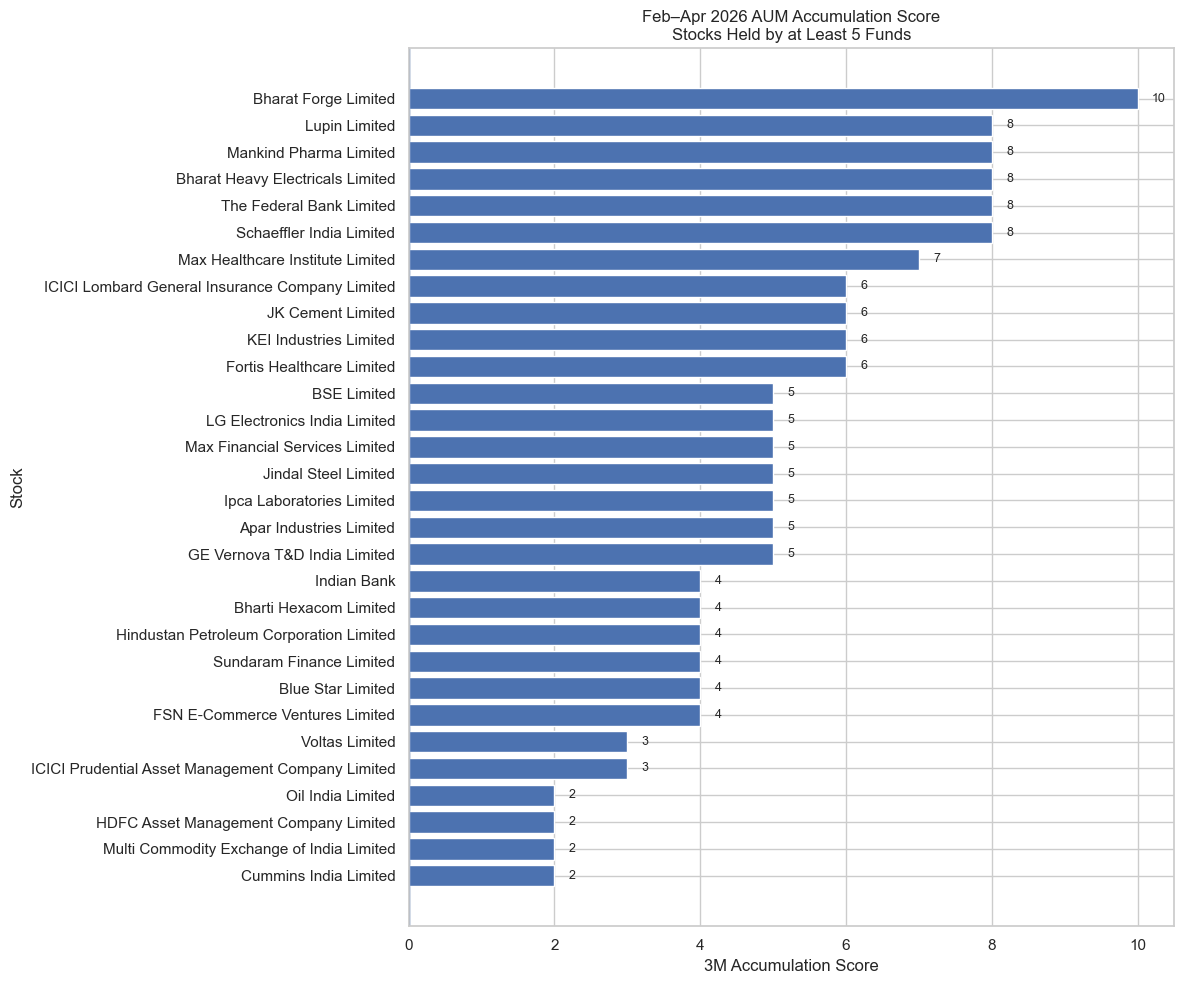

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Select top 30 or all available stocks
plot_df = aum_3m_agg.head(30).copy()

# Sort for better horizontal chart readability
plot_df = plot_df.sort_values("3M Accumulation Score", ascending=True)

plt.figure(figsize=(12, 10))

bars = plt.barh(
    plot_df["Stock"],
    plot_df["3M Accumulation Score"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("3M Accumulation Score")
plt.ylabel("Stock")
plt.title("Feb–Apr 2026 AUM Accumulation Score\nStocks Held by at Least 5 Funds")

# Add score labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (0.2 if width >= 0 else -0.2),
        bar.get_y() + bar.get_height() / 2,
        f"{width:.0f}",
        va="center",
        ha="left" if width >= 0 else "right",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [32]:
import yfinance as yf
import pandas as pd
import numpy as np

# 30 stocks from Mid-cap AUM Accumulation Score chart
stocks_30 = {
    # Strongest Accumulators
    "The Federal Bank Limited": "FEDERALBNK.NS",
    "Lupin Limited": "LUPIN.NS",
    "GE Vernova T&D India Limited": "GVT&D.NS",
    "Bharat Forge Limited": "BHARATFORG.NS",
    "Jindal Steel Limited": "JINDALSTEL.NS",
    "Multi Commodity Exchange of India Limited": "MCX.NS",
    "ICICI Prudential Asset Management Company Limited": "ICICIAMC.NS",
    "Oil India Limited": "OIL.NS",
    "Mankind Pharma Limited": "MANKIND.NS",
    "Hindustan Petroleum Corporation Limited": "HINDPETRO.NS",
    "Indus Towers Limited": "INDUSTOWER.NS",
    "APL Apollo Tubes Limited": "APLAPOLLO.NS",
    "PB Fintech Limited": "POLICYBZR.NS",
    "BSE Limited": "BSE.NS",
    "Billionbrains Garage Ventures Limited": "GROWW.NS",
    "Swiggy Limited": "SWIGGY.NS",
    "Oberoi Realty Limited": "OBEROIRLTY.NS",
    "Max Financial Services Limited": "MFSL.NS",
    "Voltas Limited": "VOLTAS.NS",
    "Mahindra & Mahindra Financial Services Limited": "M&MFIN.NS",
    "Cummins India Limited": "CUMMINSIND.NS",
    "PI Industries Limited": "PIIND.NS",
    "The Indian Hotels Company Limited": "INDHOTEL.NS",
    "Prestige Estates Projects Limited": "PRESTIGE.NS",
    "Dixon Technologies (India) Limited": "DIXON.NS",
    "Page Industries Limited": "PAGEIND.NS",
    "Eternal Limited": "ETERNAL.NS",
    "HDB Financial Services Limited": "HDBFS.NS",
    "Mphasis Limited": "MPHASIS.NS",
    "Persistent Systems Limited": "PERSISTENT.NS"
}

# 3-month return period
start_date = "2026-01-31"
end_date = "2026-04-30"

# Download buffer
start_download = "2026-01-20"
end_download = "2026-05-05"


def get_nearest_price(price_series, target_date):
    """
    Use nearest available trading price on or before target date.
    """
    target_date = pd.to_datetime(target_date)
    available = price_series[price_series.index <= target_date]

    if available.empty:
        return np.nan, None

    return available.iloc[-1], available.index[-1].date()


three_month_results = []

for stock_name, ticker in stocks_30.items():
    try:
        data = yf.download(
            ticker,
            start=start_download,
            end=end_download,
            auto_adjust=True,
            progress=False,
            multi_level_index=False
        )

        if data.empty:
            three_month_results.append({
                "Stock": stock_name,
                "Ticker": ticker,
                "3M Start Date": None,
                "3M Start Price": np.nan,
                "3M End Date": None,
                "3M End Price": np.nan,
                "3M Return (%)": np.nan,
                "Error": "No data found"
            })
            continue

        price = data["Close"].dropna()

        start_price, actual_start_date = get_nearest_price(price, start_date)
        end_price, actual_end_date = get_nearest_price(price, end_date)

        if pd.isna(start_price) or pd.isna(end_price):
            three_m_return = np.nan
        else:
            three_m_return = ((end_price / start_price) - 1) * 100

        three_month_results.append({
            "Stock": stock_name,
            "Ticker": ticker,
            "3M Start Date": actual_start_date,
            "3M Start Price": round(float(start_price), 2) if pd.notna(start_price) else np.nan,
            "3M End Date": actual_end_date,
            "3M End Price": round(float(end_price), 2) if pd.notna(end_price) else np.nan,
            "3M Return (%)": round(float(three_m_return), 2) if pd.notna(three_m_return) else np.nan,
            "Error": None
        })

    except Exception as e:
        three_month_results.append({
            "Stock": stock_name,
            "Ticker": ticker,
            "3M Start Date": None,
            "3M Start Price": np.nan,
            "3M End Date": None,
            "3M End Price": np.nan,
            "3M Return (%)": np.nan,
            "Error": str(e)
        })


three_m_return_df = pd.DataFrame(three_month_results)

# Sort by 3M return
three_m_return_df = three_m_return_df.sort_values(
    by="3M Return (%)",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

display(three_m_return_df)

three_m_return_df.to_csv(
    "midcap_30_stocks_3m_return.csv",
    index=False
)

,Stock,Ticker,3M Start Date,3M Start Price,3M End Date,3M End Price,3M Return (%),Error
0,GE Vernova T&D India Limited,GVT&D.NS,2026-01-30,3230.30,2026-04-30,4466.20,38.26,None
1,Bharat Forge Limited,BHARATFORG.NS,2026-01-30,1439.75,2026-04-30,1881.60,30.69,None
2,BSE Limited,BSE.NS,2026-01-30,2797.00,2026-04-30,3640.50,30.16,None
3,Cummins India Limited,CUMMINSIND.NS,2026-01-30,4093.88,2026-04-30,5266.40,28.64,None
4,Billionbrains Garage Ventures Limited,GROWW.NS,2026-01-30,177.04,2026-04-30,214.99,21.44,None
5,Multi Commodity Exchange of India Limited,MCX.NS,2026-01-30,2528.00,2026-04-30,2971.50,17.54,None
6,Oberoi Realty Limited,OBEROIRLTY.NS,2026-01-30,1489.06,2026-04-30,1667.54,11.99,None
7,Page Industries Limited,PAGEIND.NS,2026-01-30,32747.06,2026-04-30,36640.95,11.89,None
8,ICICI Prudential Asset Management Company Limited,ICICIAMC.NS,2026-01-30,2972.60,2026-04-30,3290.20,10.68,None
9,Jindal Steel Limited,JINDALSTEL.NS,2026-01-30,1132.00,2026-04-30,1223.10,8.05,None


In [33]:
# --- Final 3-column table: Stock | 3M Return | 3M Accumulation Score ---

# 1. Prepare 3M return table
return_3m_table = three_m_return_df[
    ["Stock", "3M Return (%)"]
].copy()

# 2. Prepare 3M AUM accumulation score table
acc_3m_score_table = aum_3m_agg[
    ["Stock", "3M Accumulation Score"]
].copy()


# 3. Clean stock names for safe matching
def clean_stock_name(x):
    x = str(x).lower()
    x = x.replace("limited", "")
    x = x.replace("ltd", "")
    x = x.replace(".", "")
    x = x.replace("&", "and")
    x = x.replace("-", " ")
    x = x.replace("(", "")
    x = x.replace(")", "")
    x = " ".join(x.split())
    return x


return_3m_table["Clean Stock"] = return_3m_table["Stock"].apply(clean_stock_name)
acc_3m_score_table["Clean Stock"] = acc_3m_score_table["Stock"].apply(clean_stock_name)


# 4. Merge 3M return with 3M accumulation score
final_30_3m_accumulation = return_3m_table.merge(
    acc_3m_score_table[["Clean Stock", "3M Accumulation Score"]],
    on="Clean Stock",
    how="left"
)


# 5. Keep only required 3 columns
final_30_3m_accumulation = final_30_3m_accumulation[
    [
        "Stock",
        "3M Return (%)",
        "3M Accumulation Score"
    ]
].copy()


# 6. Convert to numeric
final_30_3m_accumulation["3M Return (%)"] = pd.to_numeric(
    final_30_3m_accumulation["3M Return (%)"],
    errors="coerce"
)

final_30_3m_accumulation["3M Accumulation Score"] = pd.to_numeric(
    final_30_3m_accumulation["3M Accumulation Score"],
    errors="coerce"
)


# 7. Sort by 3M return
final_30_3m_accumulation = final_30_3m_accumulation.sort_values(
    by="3M Return (%)",
    ascending=False,
    na_position="last"
).reset_index(drop=True)


# 8. Display final table
display(final_30_3m_accumulation)


# 9. Save output
final_30_3m_accumulation.to_csv(
    "midcap_30_stocks_3m_return_3m_accumulation_score.csv",
    index=False
)

,Stock,3M Return (%),3M Accumulation Score
0,GE Vernova T&D India Limited,38.26,5
1,Bharat Forge Limited,30.69,10
2,BSE Limited,30.16,5
3,Cummins India Limited,28.64,2
4,Billionbrains Garage Ventures Limited,21.44,1
5,Multi Commodity Exchange of India Limited,17.54,2
6,Oberoi Realty Limited,11.99,-1
7,Page Industries Limited,11.89,-4
8,ICICI Prudential Asset Management Company Limited,10.68,3
9,Jindal Steel Limited,8.05,5


In [35]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Use your final 3-column table
analysis_3m = final_30_3m_accumulation.copy()

# Convert columns to numeric
analysis_3m["3M Return (%)"] = pd.to_numeric(
    analysis_3m["3M Return (%)"],
    errors="coerce"
)

analysis_3m["3M Accumulation Score"] = pd.to_numeric(
    analysis_3m["3M Accumulation Score"],
    errors="coerce"
)

# Drop missing values
analysis_3m = analysis_3m.dropna(
    subset=["3M Return (%)", "3M Accumulation Score"]
).copy()

display(analysis_3m)

,Stock,3M Return (%),3M Accumulation Score
0,GE Vernova T&D India Limited,38.26,5
1,Bharat Forge Limited,30.69,10
2,BSE Limited,30.16,5
3,Cummins India Limited,28.64,2
4,Billionbrains Garage Ventures Limited,21.44,1
5,Multi Commodity Exchange of India Limited,17.54,2
6,Oberoi Realty Limited,11.99,-1
7,Page Industries Limited,11.89,-4
8,ICICI Prudential Asset Management Company Limited,10.68,3
9,Jindal Steel Limited,8.05,5


In [36]:
x = analysis_3m["3M Accumulation Score"]
y = analysis_3m["3M Return (%)"]

pearson_corr, pearson_p = pearsonr(x, y)
spearman_corr, spearman_p = spearmanr(x, y)

corr_3m_table = pd.DataFrame({
    "Method": ["Pearson Correlation", "Spearman Rank Correlation"],
    "Correlation": [round(pearson_corr, 6), round(spearman_corr, 6)],
    "P-value": [round(pearson_p, 6), round(spearman_p, 6)]
})

display(corr_3m_table)

,Method,Correlation,P-value
0,Pearson Correlation,0.617308,0.000279
1,Spearman Rank Correlation,0.631019,0.000185


In [37]:
X = analysis_3m[["3M Accumulation Score"]]
Y = analysis_3m["3M Return (%)"]

X = sm.add_constant(X)

model_3m = sm.OLS(Y, X).fit()

print(model_3m.summary())

                            OLS Regression Results                            
Dep. Variable:          3M Return (%)   R-squared:                       0.381
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     17.24
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           0.000279
Time:                        13:35:26   Log-Likelihood:                -116.78
No. Observations:                  30   AIC:                             237.6
Df Residuals:                      28   BIC:                             240.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     2.31

In [38]:
reg_3m_summary = pd.DataFrame({
    "Metric": [
        "Alpha / Intercept",
        "Beta: 3M Accumulation Score",
        "R-squared",
        "Adjusted R-squared",
        "P-value of Beta",
        "Observations"
    ],
    "Value": [
        round(model_3m.params["const"], 4),
        round(model_3m.params["3M Accumulation Score"], 4),
        round(model_3m.rsquared, 4),
        round(model_3m.rsquared_adj, 4),
        round(model_3m.pvalues["3M Accumulation Score"], 4),
        int(model_3m.nobs)
    ]
})

display(reg_3m_summary)

,Metric,Value
0,Alpha / Intercept,2.3188
1,Beta: 3M Accumulation Score,1.8470
2,R-squared,0.3811
3,Adjusted R-squared,0.3590
4,P-value of Beta,0.0003
5,Observations,30.0000


### Taking an important Note here that I selected the usual 30 stocks of the 5M analysis ###

In [39]:
# Top 15 3M Accumulators
top_15_3m_accumulators = aum_3m_agg.sort_values(
    ["3M Accumulation Score", "Net_3M_AUM_Change_Cr"],
    ascending=False
).head(15).reset_index(drop=True)

top_15_3m_accumulators.insert(
    0,
    "Rank",
    top_15_3m_accumulators.index + 1
)

print("📈 Top 15 3M Accumulators — Feb to Apr 2026")
display(
    top_15_3m_accumulators[
        [
            "Rank",
            "Stock",
            "Funds_Tracked",
            "Total_Feb_Change_Cr",
            "Total_Mar_Change_Cr",
            "Total_Apr_Change_Cr",
            "Net_3M_AUM_Change_Cr",
            "Total_3M_Increase_Months",
            "Total_3M_Decrease_Months",
            "3M Accumulation Score",
            "3M_AUM_Increase_Ratio",
            "3M_AUM_Decrease_Ratio"
        ]
    ]
)

📈 Top 15 3M Accumulators — Feb to Apr 2026


,Rank,Stock,Funds_Tracked,Total_Feb_Change_Cr,Total_Mar_Change_Cr,Total_Apr_Change_Cr,Net_3M_AUM_Change_Cr,Total_3M_Increase_Months,Total_3M_Decrease_Months,3M Accumulation Score,3M_AUM_Increase_Ratio,3M_AUM_Decrease_Ratio
0,1,Bharat Forge Limited,9,1301.70,-587.72,465.13,1179.11,18,8,10,0.67,0.30
1,2,Bharat Heavy Electricals Limited,6,187.09,91.53,1073.46,1352.08,12,4,8,0.67,0.22
2,3,Lupin Limited,6,116.96,244.11,234.57,595.64,12,4,8,0.67,0.22
3,4,Mankind Pharma Limited,5,152.71,65.37,336.14,554.22,11,3,8,0.73,0.20
4,5,Schaeffler India Limited,8,600.94,-266.32,88.93,423.55,15,7,8,0.62,0.29
5,6,The Federal Bank Limited,9,467.63,-1545.49,919.94,-157.92,17,9,8,0.63,0.33
6,7,Max Healthcare Institute Limited,6,463.64,-106.00,208.13,565.77,11,4,7,0.61,0.22
7,8,Fortis Healthcare Limited,6,1102.36,-1399.68,1352.80,1055.48,12,6,6,0.67,0.33
8,9,KEI Industries Limited,6,1158.39,-1066.80,801.75,893.34,12,6,6,0.67,0.33
9,10,ICICI Lombard General Insurance Company Limited,5,94.57,-106.50,113.54,101.61,10,4,6,0.67,0.27


In [40]:
# Top 15 3M Distributors
top_15_3m_distributors = aum_3m_agg.sort_values(
    ["3M Accumulation Score", "Net_3M_AUM_Change_Cr"],
    ascending=True
).head(15).reset_index(drop=True)

top_15_3m_distributors.insert(
    0,
    "Rank",
    top_15_3m_distributors.index + 1
)

print("📉 Top 15 3M Distributors — Feb to Apr 2026")
display(
    top_15_3m_distributors[
        [
            "Rank",
            "Stock",
            "Funds_Tracked",
            "Total_Feb_Change_Cr",
            "Total_Mar_Change_Cr",
            "Total_Apr_Change_Cr",
            "Net_3M_AUM_Change_Cr",
            "Total_3M_Increase_Months",
            "Total_3M_Decrease_Months",
            "3M Accumulation Score",
            "3M_AUM_Increase_Ratio",
            "3M_AUM_Decrease_Ratio"
        ]
    ]
)

📉 Top 15 3M Distributors — Feb to Apr 2026


,Rank,Stock,Funds_Tracked,Total_Feb_Change_Cr,Total_Mar_Change_Cr,Total_Apr_Change_Cr,Net_3M_AUM_Change_Cr,Total_3M_Increase_Months,Total_3M_Decrease_Months,3M Accumulation Score,3M_AUM_Increase_Ratio,3M_AUM_Decrease_Ratio
0,1,Persistent Systems Limited,8,-2763.57,-112.13,-123.77,-2999.47,6,18,-12,0.25,0.75
1,2,Mphasis Limited,8,-741.85,-293.93,622.67,-413.11,5,12,-7,0.21,0.50
2,3,Eternal Limited,7,-518.25,-419.42,831.76,-105.91,7,14,-7,0.33,0.67
3,4,Bharat Electronics Limited,6,292.22,-231.87,193.96,254.31,6,12,-6,0.33,0.67
4,5,Mahindra & Mahindra Financial Services Limited,5,37.62,-916.12,38.37,-840.13,4,9,-5,0.27,0.60
5,6,Coromandel International Limited,5,-104.33,-497.72,154.06,-447.99,5,10,-5,0.33,0.67
6,7,Swiggy Limited,6,-164.80,-177.77,202.97,-139.60,7,11,-4,0.39,0.61
7,8,Prestige Estates Projects Limited,6,160.95,-413.72,346.42,93.65,6,10,-4,0.33,0.56
8,9,Page Industries Limited,5,-21.15,-11.21,281.46,249.10,5,9,-4,0.33,0.60
9,10,Vishal Mega Mart Limited,6,155.50,-454.91,948.42,649.01,7,11,-4,0.39,0.61


In [41]:
top_15_3m_accumulators.to_csv(
    "top_15_3m_accumulators_feb_apr_2026.csv",
    index=False
)

top_15_3m_distributors.to_csv(
    "top_15_3m_distributors_feb_apr_2026.csv",
    index=False
)

In [42]:
top_15_3m_accumulators["Flow Category"] = "Accumulator"
top_15_3m_accumulators["Accumulator Dummy"] = 1
top_15_3m_accumulators["Distributor Dummy"] = 0

top_15_3m_distributors["Flow Category"] = "Distributor"
top_15_3m_distributors["Accumulator Dummy"] = 0
top_15_3m_distributors["Distributor Dummy"] = 1

top_30_3m_flow = pd.concat(
    [top_15_3m_accumulators, top_15_3m_distributors],
    ignore_index=True
)

display(top_30_3m_flow)

top_30_3m_flow.to_csv(
    "top_30_3m_accumulators_distributors_feb_apr_2026.csv",
    index=False
)

,Rank,Stock,Funds_Tracked,Total_Feb_Change_Cr,Total_Mar_Change_Cr,Total_Apr_Change_Cr,Total_3M_Increase_Months,Total_3M_Decrease_Months,Total_3M_No_Change_Months,Total_3M_Periods,Net_3M_AUM_Change_Cr,Avg_3M_AUM_Change_Cr,3M_AUM_Increase_Ratio,3M_AUM_Decrease_Ratio,3M Accumulation Score,Flow Category,Accumulator Dummy,Distributor Dummy
0,1,Bharat Forge Limited,9,1301.70,-587.72,465.13,18,8,1,27,1179.11,131.01,0.67,0.30,10,Accumulator,1,0
1,2,Bharat Heavy Electricals Limited,6,187.09,91.53,1073.46,12,4,2,18,1352.08,225.35,0.67,0.22,8,Accumulator,1,0
2,3,Lupin Limited,6,116.96,244.11,234.57,12,4,2,18,595.64,99.27,0.67,0.22,8,Accumulator,1,0
3,4,Mankind Pharma Limited,5,152.71,65.37,336.14,11,3,1,15,554.22,110.84,0.73,0.20,8,Accumulator,1,0
4,5,Schaeffler India Limited,8,600.94,-266.32,88.93,15,7,2,24,423.55,52.94,0.62,0.29,8,Accumulator,1,0
5,6,The Federal Bank Limited,9,467.63,-1545.49,919.94,17,9,1,27,-157.92,-17.55,0.63,0.33,8,Accumulator,1,0
6,7,Max Healthcare Institute Limited,6,463.64,-106.00,208.13,11,4,3,18,565.77,94.30,0.61,0.22,7,Accumulator,1,0
7,8,Fortis Healthcare Limited,6,1102.36,-1399.68,1352.80,12,6,0,18,1055.48,175.91,0.67,0.33,6,Accumulator,1,0
8,9,KEI Industries Limited,6,1158.39,-1066.80,801.75,12,6,0,18,893.34,148.89,0.67,0.33,6,Accumulator,1,0
9,10,ICICI Lombard General Insurance Company Limited,5,94.57,-106.50,113.54,10,4,1,15,101.61,20.32,0.67,0.27,6,Accumulator,1,0


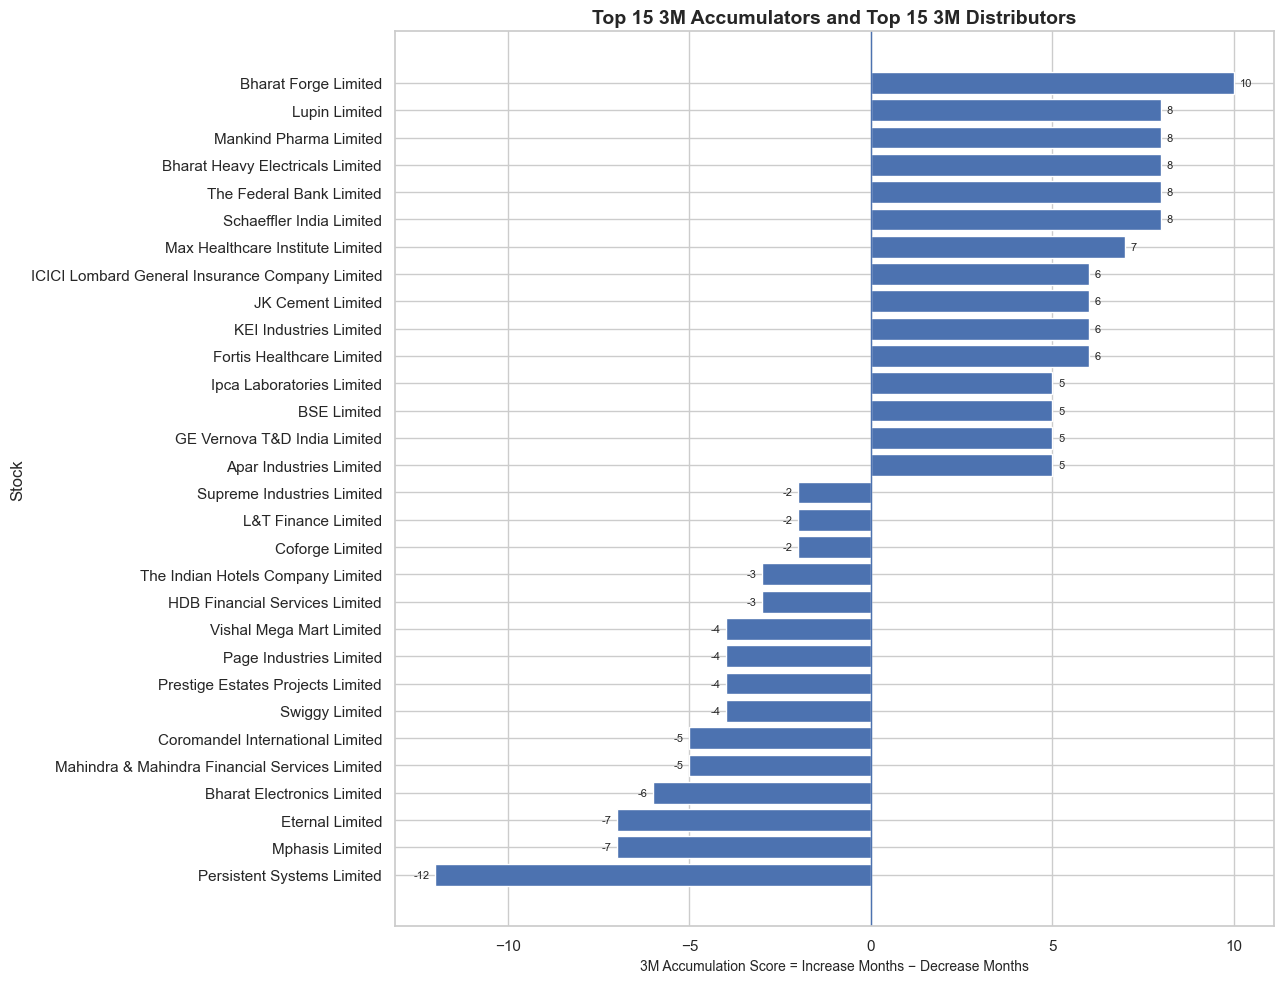

In [43]:
combined_3m_flow = pd.concat(
    [
        top_15_3m_accumulators.assign(Category="Accumulator"),
        top_15_3m_distributors.assign(Category="Distributor")
    ],
    ignore_index=True
)

combined_3m_flow = combined_3m_flow.sort_values(
    "3M Accumulation Score",
    ascending=True
)

fig, ax = plt.subplots(figsize=(13, 10))

bars = ax.barh(
    combined_3m_flow["Stock"],
    combined_3m_flow["3M Accumulation Score"]
)

ax.axvline(0, linewidth=1)

ax.bar_label(
    bars,
    labels=[f"{v:.0f}" for v in combined_3m_flow["3M Accumulation Score"]],
    padding=4,
    fontsize=8
)

ax.set_title(
    "Top 15 3M Accumulators and Top 15 3M Distributors",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "3M Accumulation Score = Increase Months − Decrease Months",
    fontsize=10
)

ax.set_ylabel("Stock")

plt.subplots_adjust(left=0.40, right=0.95)
plt.tight_layout()
plt.show()

In [44]:
import yfinance as yf
import pandas as pd
import numpy as np

# 30 stocks from latest 3M accumulator/distributor graph
stocks_30_3m = {
    # Top 15 3M Accumulators
    "Bharat Forge Limited": "BHARATFORG.NS",
    "Lupin Limited": "LUPIN.NS",
    "Mankind Pharma Limited": "MANKIND.NS",
    "Bharat Heavy Electricals Limited": "BHEL.NS",
    "The Federal Bank Limited": "FEDERALBNK.NS",
    "Schaeffler India Limited": "SCHAEFFLER.NS",
    "Max Healthcare Institute Limited": "MAXHEALTH.NS",
    "ICICI Lombard General Insurance Company Limited": "ICICIGI.NS",
    "JK Cement Limited": "JKCEMENT.NS",
    "KEI Industries Limited": "KEI.NS",
    "Fortis Healthcare Limited": "FORTIS.NS",
    "Ipca Laboratories Limited": "IPCALAB.NS",
    "BSE Limited": "BSE.NS",
    "GE Vernova T&D India Limited": "GVT&D.NS",
    "Apar Industries Limited": "APARINDS.NS",

    # Top 15 3M Distributors
    "Supreme Industries Limited": "SUPREMEIND.NS",
    "L&T Finance Limited": "LTF.NS",
    "Coforge Limited": "COFORGE.NS",
    "The Indian Hotels Company Limited": "INDHOTEL.NS",
    "HDB Financial Services Limited": "HDBFS.NS",
    "Vishal Mega Mart Limited": "VMM.NS",
    "Page Industries Limited": "PAGEIND.NS",
    "Prestige Estates Projects Limited": "PRESTIGE.NS",
    "Swiggy Limited": "SWIGGY.NS",
    "Coromandel International Limited": "COROMANDEL.NS",
    "Mahindra & Mahindra Financial Services Limited": "M&MFIN.NS",
    "Bharat Electronics Limited": "BEL.NS",
    "Eternal Limited": "ETERNAL.NS",
    "Mphasis Limited": "MPHASIS.NS",
    "Persistent Systems Limited": "PERSISTENT.NS"
}

# 3-month return period
start_date = "2026-01-31"
end_date = "2026-04-30"

# Download buffer
start_download = "2026-01-20"
end_download = "2026-05-05"


def get_nearest_price(price_series, target_date):
    """
    Use nearest available trading price on or before target date.
    """
    target_date = pd.to_datetime(target_date)
    available = price_series[price_series.index <= target_date]

    if available.empty:
        return np.nan, None

    return available.iloc[-1], available.index[-1].date()


three_month_results = []

for stock_name, ticker in stocks_30_3m.items():
    try:
        data = yf.download(
            ticker,
            start=start_download,
            end=end_download,
            auto_adjust=True,
            progress=False,
            multi_level_index=False
        )

        if data.empty:
            three_month_results.append({
                "Stock": stock_name,
                "Ticker": ticker,
                "3M Start Date": None,
                "3M Start Price": np.nan,
                "3M End Date": None,
                "3M End Price": np.nan,
                "3M Return (%)": np.nan,
                "Error": "No data found"
            })
            continue

        price = data["Close"].dropna()

        start_price, actual_start_date = get_nearest_price(price, start_date)
        end_price, actual_end_date = get_nearest_price(price, end_date)

        if pd.isna(start_price) or pd.isna(end_price):
            three_m_return = np.nan
        else:
            three_m_return = ((end_price / start_price) - 1) * 100

        three_month_results.append({
            "Stock": stock_name,
            "Ticker": ticker,
            "3M Start Date": actual_start_date,
            "3M Start Price": round(float(start_price), 2) if pd.notna(start_price) else np.nan,
            "3M End Date": actual_end_date,
            "3M End Price": round(float(end_price), 2) if pd.notna(end_price) else np.nan,
            "3M Return (%)": round(float(three_m_return), 2) if pd.notna(three_m_return) else np.nan,
            "Error": None
        })

    except Exception as e:
        three_month_results.append({
            "Stock": stock_name,
            "Ticker": ticker,
            "3M Start Date": None,
            "3M Start Price": np.nan,
            "3M End Date": None,
            "3M End Price": np.nan,
            "3M Return (%)": np.nan,
            "Error": str(e)
        })


three_m_return_df = pd.DataFrame(three_month_results)

# Sort by 3M return
three_m_return_df = three_m_return_df.sort_values(
    by="3M Return (%)",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

display(three_m_return_df)

three_m_return_df.to_csv(
    "midcap_latest_top15_accumulators_distributors_3m_return.csv",
    index=False
)

,Stock,Ticker,3M Start Date,3M Start Price,3M End Date,3M End Price,3M Return (%),Error
0,Apar Industries Limited,APARINDS.NS,2026-01-30,7994.00,2026-04-30,12331.00,54.25,None
1,GE Vernova T&D India Limited,GVT&D.NS,2026-01-30,3230.30,2026-04-30,4466.20,38.26,None
2,Bharat Heavy Electricals Limited,BHEL.NS,2026-01-30,262.70,2026-04-30,352.41,34.15,None
3,Bharat Forge Limited,BHARATFORG.NS,2026-01-30,1439.75,2026-04-30,1881.60,30.69,None
4,BSE Limited,BSE.NS,2026-01-30,2797.00,2026-04-30,3640.50,30.16,None
5,KEI Industries Limited,KEI.NS,2026-01-30,4021.10,2026-04-30,4857.50,20.80,None
6,Schaeffler India Limited,SCHAEFFLER.NS,2026-01-30,3592.54,2026-04-30,4124.80,14.82,None
7,Page Industries Limited,PAGEIND.NS,2026-01-30,32747.06,2026-04-30,36640.95,11.89,None
8,Fortis Healthcare Limited,FORTIS.NS,2026-01-30,851.50,2026-04-30,922.95,8.39,None
9,Lupin Limited,LUPIN.NS,2026-01-30,2152.80,2026-04-30,2305.20,7.08,None


In [45]:
# --- Final 3-column table: Stock | 3M Return | 3M Accumulation Score ---

import pandas as pd
import numpy as np

# 1. Prepare 3M return table
return_3m_table = three_m_return_df[
    ["Stock", "3M Return (%)"]
].copy()

# 2. Prepare 3M accumulation score table
acc_3m_score_table = aum_3m_agg[
    ["Stock", "3M Accumulation Score"]
].copy()


# 3. Clean stock names for safer matching
def clean_stock_name(x):
    x = str(x).lower()
    x = x.replace("limited", "")
    x = x.replace("ltd", "")
    x = x.replace(".", "")
    x = x.replace("&", "and")
    x = x.replace("-", " ")
    x = x.replace("(", "")
    x = x.replace(")", "")
    x = " ".join(x.split())
    return x


return_3m_table["Clean Stock"] = return_3m_table["Stock"].apply(clean_stock_name)
acc_3m_score_table["Clean Stock"] = acc_3m_score_table["Stock"].apply(clean_stock_name)


# 4. Merge 3M return with 3M accumulation score
final_30_3m_table = return_3m_table.merge(
    acc_3m_score_table[["Clean Stock", "3M Accumulation Score"]],
    on="Clean Stock",
    how="left"
)


# 5. Keep only required 3 columns
final_30_3m_table = final_30_3m_table[
    [
        "Stock",
        "3M Return (%)",
        "3M Accumulation Score"
    ]
].copy()


# 6. Coerce numeric columns
final_30_3m_table["3M Return (%)"] = pd.to_numeric(
    final_30_3m_table["3M Return (%)"],
    errors="coerce"
)

final_30_3m_table["3M Accumulation Score"] = pd.to_numeric(
    final_30_3m_table["3M Accumulation Score"],
    errors="coerce"
)


# 7. Sort by 3M return
final_30_3m_table = final_30_3m_table.sort_values(
    by="3M Return (%)",
    ascending=False,
    na_position="last"
).reset_index(drop=True)


# 8. Display final table
display(final_30_3m_table)


# 9. Save output
final_30_3m_table.to_csv(
    "midcap_top15_accum_dist_3m_return_3m_accumulation_score.csv",
    index=False
)

,Stock,3M Return (%),3M Accumulation Score
0,Apar Industries Limited,54.25,5
1,GE Vernova T&D India Limited,38.26,5
2,Bharat Heavy Electricals Limited,34.15,8
3,Bharat Forge Limited,30.69,10
4,BSE Limited,30.16,5
5,KEI Industries Limited,20.80,6
6,Schaeffler India Limited,14.82,8
7,Page Industries Limited,11.89,-4
8,Fortis Healthcare Limited,8.39,6
9,Lupin Limited,7.08,8


In [46]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Use your final 3-column table
analysis_3m = final_30_3m_table.copy()

# Coerce numeric
analysis_3m["3M Return (%)"] = pd.to_numeric(
    analysis_3m["3M Return (%)"],
    errors="coerce"
)

analysis_3m["3M Accumulation Score"] = pd.to_numeric(
    analysis_3m["3M Accumulation Score"],
    errors="coerce"
)

# Drop missing rows
analysis_3m = analysis_3m.dropna(
    subset=["3M Return (%)", "3M Accumulation Score"]
).copy()

display(analysis_3m)

,Stock,3M Return (%),3M Accumulation Score
0,Apar Industries Limited,54.25,5
1,GE Vernova T&D India Limited,38.26,5
2,Bharat Heavy Electricals Limited,34.15,8
3,Bharat Forge Limited,30.69,10
4,BSE Limited,30.16,5
5,KEI Industries Limited,20.80,6
6,Schaeffler India Limited,14.82,8
7,Page Industries Limited,11.89,-4
8,Fortis Healthcare Limited,8.39,6
9,Lupin Limited,7.08,8


In [47]:
x = analysis_3m["3M Accumulation Score"]
y = analysis_3m["3M Return (%)"]

pearson_corr, pearson_p = pearsonr(x, y)
spearman_corr, spearman_p = spearmanr(x, y)

corr_3m_table = pd.DataFrame({
    "Method": ["Pearson Correlation", "Spearman Rank Correlation"],
    "Correlation": [round(pearson_corr, 6), round(spearman_corr, 6)],
    "P-value": [round(pearson_p, 6), round(spearman_p, 6)]
})

display(corr_3m_table)

,Method,Correlation,P-value
0,Pearson Correlation,0.652038,0.000095
1,Spearman Rank Correlation,0.698996,0.000017


In [49]:
X = analysis_3m[["3M Accumulation Score"]]
Y = analysis_3m["3M Return (%)"]

X = sm.add_constant(X)

model_3m = sm.OLS(Y, X).fit()

print(model_3m.summary())

                            OLS Regression Results                            
Dep. Variable:          3M Return (%)   R-squared:                       0.425
Model:                            OLS   Adj. R-squared:                  0.405
Method:                 Least Squares   F-statistic:                     20.71
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           9.46e-05
Time:                        13:44:19   Log-Likelihood:                -121.87
No. Observations:                  30   AIC:                             247.7
Df Residuals:                      28   BIC:                             250.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.83

In [50]:
reg_3m_summary = pd.DataFrame({
    "Metric": [
        "Alpha / Intercept",
        "Beta: 3M Accumulation Score",
        "R-squared",
        "Adjusted R-squared",
        "P-value of Beta",
        "Observations"
    ],
    "Value": [
        round(model_3m.params["const"], 4),
        round(model_3m.params["3M Accumulation Score"], 4),
        round(model_3m.rsquared, 4),
        round(model_3m.rsquared_adj, 4),
        round(model_3m.pvalues["3M Accumulation Score"], 4),
        int(model_3m.nobs)
    ]
})

display(reg_3m_summary)

,Metric,Value
0,Alpha / Intercept,1.8352
1,Beta: 3M Accumulation Score,1.9940
2,R-squared,0.4252
3,Adjusted R-squared,0.4046
4,P-value of Beta,0.0001
5,Observations,30.0000


### The mid-cap 3M analysis shows a strong positive relationship between mutual fund accumulation and short-term price momentum. The Pearson correlation is 0.652, and the Spearman rank correlation is 0.699, suggesting that stocks with higher accumulation scores also tend to rank better in 3-month returns. The regression coefficient is 1.994, statistically significant at the 1% level, and the model explains around 42.5% of the cross-sectional variation in returns. This supports the use of 3M AUM accumulation score as a meaningful stock-selection signal in the mid-cap universe. ###

---
## Analysis 9 — New Entries & Exits
**Question:** Which stocks entered or exited each fund's portfolio during Nov-25 to Apr-26?

#### New Entry = stock was missing/zero in Nov-25 but appears with positive AUM by Apr-26 ####
#### Exit = stock had positive AUM in Nov-25 but is missing/zero by Apr-26 ####

In [53]:
## Analysis 9— New Entries & Exits
# Question: Which stocks entered or exited each fund's portfolio during Nov-25 to Apr-26?

START_MONTH = "2025-11"
END_MONTH = "2026-04"

entry_exit_data = []

for fund, df in raw_data.items():
    
    df = df.replace("-", np.nan).copy()
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # If same stock appears more than once, combine stock-wise AUM
    df = df.groupby(df.index).sum(numeric_only=True)
    
    if START_MONTH not in df.columns or END_MONTH not in df.columns:
        print(f"⚠️ Skipping {fund} — missing start or end month")
        continue
    
    start = df[START_MONTH]
    end = df[END_MONTH]
    
    # Treat NaN as 0 for entry/exit identification
    start_filled = start.fillna(0)
    end_filled = end.fillna(0)
    
    # New Entry: zero/missing at start, positive at end
    new_entries = df[(start_filled <= 0) & (end_filled > 0)].copy()
    
    # Exit: positive at start, zero/missing at end
    exits = df[(start_filled > 0) & (end_filled <= 0)].copy()
    
    for stock in new_entries.index:
        entry_exit_data.append({
            "Fund": fund,
            "Stock": stock,
            "Status": "New Entry",
            "Start AUM (₹ Cr)": round(start_filled.loc[stock], 2),
            "End AUM (₹ Cr)": round(end_filled.loc[stock], 2),
            "AUM Change (₹ Cr)": round(end_filled.loc[stock] - start_filled.loc[stock], 2)
        })
    
    for stock in exits.index:
        entry_exit_data.append({
            "Fund": fund,
            "Stock": stock,
            "Status": "Exit",
            "Start AUM (₹ Cr)": round(start_filled.loc[stock], 2),
            "End AUM (₹ Cr)": round(end_filled.loc[stock], 2),
            "AUM Change (₹ Cr)": round(end_filled.loc[stock] - start_filled.loc[stock], 2)
        })

entry_exit_df = pd.DataFrame(entry_exit_data)
# 🔥 Stocks Newly Entered in Multiple Funds

multi_new_entries = (
    entry_exit_df[entry_exit_df["Status"] == "New Entry"]
    .groupby("Stock")
    .agg(
        Number_of_Funds_Entered=("Fund", "nunique"),
        Funds_Entered=("Fund", lambda x: ", ".join(sorted(x.unique()))),
        Total_New_Entry_AUM_Cr=("End AUM (₹ Cr)", "sum")
    )
    .reset_index()
)

# Keep only stocks entered by more than 1 fund
multi_new_entries = multi_new_entries[
    multi_new_entries["Number_of_Funds_Entered"] >= 2
]

multi_new_entries = multi_new_entries.sort_values(
    ["Number_of_Funds_Entered", "Total_New_Entry_AUM_Cr"],
    ascending=False
)

print("🔥 Stocks Newly Entered in Multiple Funds:")
display(
    multi_new_entries[
        ["Stock", "Number_of_Funds_Entered", "Funds_Entered", "Total_New_Entry_AUM_Cr"]
    ].reset_index(drop=True)
)
print("🚪 Analysis 9 — New Entries & Exits")
display(entry_exit_df.reset_index(drop=True))

🔥 Stocks Newly Entered in Multiple Funds:


,Stock,Number_of_Funds_Entered,Funds_Entered,Total_New_Entry_AUM_Cr
0,Shriram Finance Limited,4,"AXIS, DSP, HSBC, MOTILAL OSWAL",1715.45
1,ICICI Prudential Asset Management Company Limited,4,"EDELWEISS, HSBC, MOTILAL OSWAL, NIPPON",1166.36
2,Multi Commodity Exchange of India Limited,3,"MOTILAL OSWAL, NIPPON, SBI",2559.69
3,JSW Energy Limited,3,"EDELWEISS, HSBC, SBI",657.55
4,Billionbrains Garage Ventures Limited,2,"EDELWEISS, MOTILAL OSWAL",1990.75
5,ICICI Bank Limited,2,"DSP, NIPPON",1240.43
6,Supreme Industries Limited,2,"EDELWEISS, SBI",719.35
7,ICICI Prudential Life Insurance Company Limited,2,"AXIS, SBI",511.03
8,Oil India Limited,2,"HSBC, MIRAE ASSET",402.49
9,Aster DM Healthcare Limited,2,"DSP, HDFC",368.67


🚪 Analysis 9 — New Entries & Exits


,Fund,Stock,Status,Start AUM (₹ Cr),End AUM (₹ Cr),AUM Change (₹ Cr)
0,HDFC,Aster DM Healthcare Limited,New Entry,0.00,255.81,255.81
1,KOTAK,Avanti Feeds Limited,New Entry,0.00,737.06,737.06
2,KOTAK,Bank of Baroda,New Entry,0.00,444.78,444.78
3,KOTAK,Bank of Maharashtra,New Entry,0.00,1251.73,1251.73
4,KOTAK,Nippon Life India Asset Management Limited,New Entry,0.00,959.45,959.45
...,...,...,...,...,...,...
157,HSBC,Oberoi Realty Limited,Exit,0.13,0.00,-0.13
158,HSBC,Prestige Estates Projects Limited,Exit,0.13,0.00,-0.13
159,HSBC,SBI Cards and Payment Services Limited,Exit,43.92,0.00,-43.92
160,HSBC,Transformers And Rectifiers (India) Limited,Exit,100.39,0.00,-100.39


In [54]:
entry_exit_summary = entry_exit_df.groupby(["Fund", "Status"]).agg(
    Stock_Count=("Stock", "count"),
    Total_AUM_Change_Cr=("AUM Change (₹ Cr)", "sum")
).round(2).reset_index()

print("📊 Fund-wise New Entries & Exits Summary")
display(entry_exit_summary)

📊 Fund-wise New Entries & Exits Summary


,Fund,Status,Stock_Count,Total_AUM_Change_Cr
0,AXIS,Exit,18,-1304.15
1,AXIS,New Entry,4,506.73
2,DSP,Exit,5,-615.50
3,DSP,New Entry,6,1404.95
4,EDELWEISS,Exit,8,-618.88
5,EDELWEISS,New Entry,12,1314.22
6,HDFC,New Entry,1,255.81
7,HSBC,Exit,14,-748.68
8,HSBC,New Entry,23,3004.08
9,KOTAK,Exit,5,-2570.38


In [55]:
stock_entry_exit_summary = entry_exit_df.groupby(["Stock", "Status"]).agg(
    Funds_Count=("Fund", "nunique"),
    Funds=("Fund", lambda x: ", ".join(sorted(x.unique()))),
    Total_AUM_Change_Cr=("AUM Change (₹ Cr)", "sum")
).round(2).reset_index()

stock_entry_exit_summary = stock_entry_exit_summary.sort_values(
    ["Status", "Funds_Count", "Total_AUM_Change_Cr"],
    ascending=[True, False, False]
)

print("📌 Stock-level Entry/Exit Summary Across Funds")
display(stock_entry_exit_summary.reset_index(drop=True))

📌 Stock-level Entry/Exit Summary Across Funds


,Stock,Status,Funds_Count,Funds,Total_AUM_Change_Cr
0,HDB Financial Services Limited,Exit,3,"AXIS, EDELWEISS, HSBC",-132.93
1,Mphasis Limited,Exit,3,"EDELWEISS, HSBC, MIRAE ASSET",-249.28
2,Godrej Properties Limited,Exit,3,"AXIS, EDELWEISS, SBI",-426.29
3,Kaynes Technology India Limited,Exit,3,"AXIS, EDELWEISS, MOTILAL OSWAL",-832.85
4,Cohance Lifesciences Limited,Exit,2,"AXIS, SBI",-64.08
...,...,...,...,...,...
121,Syngene International Limited,New Entry,1,HSBC,61.58
122,Gabriel India Limited,New Entry,1,HSBC,18.74
123,Bosch Home Comfort India Limited,New Entry,1,HSBC,12.05
124,Meesho Limited,New Entry,1,EDELWEISS,4.77


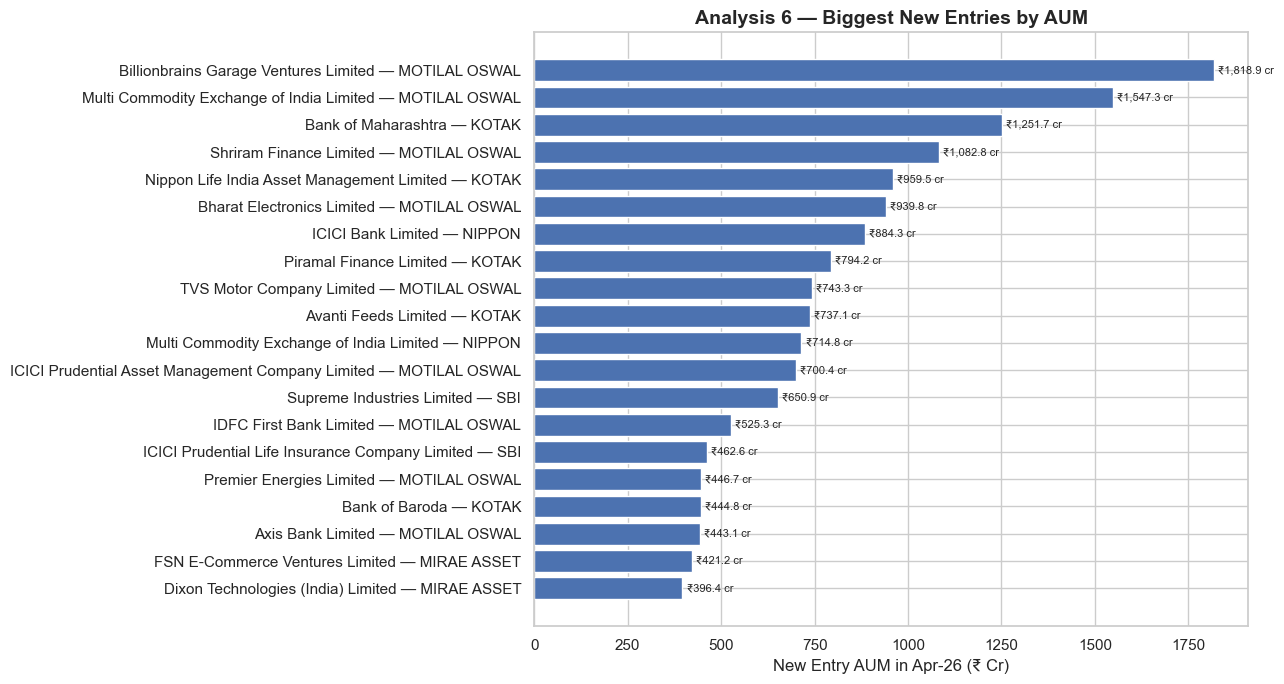

In [56]:
top_new_entries = entry_exit_df[
    entry_exit_df["Status"] == "New Entry"
].sort_values(
    "AUM Change (₹ Cr)",
    ascending=False
).head(20)

top_new_entries_plot = top_new_entries.sort_values("AUM Change (₹ Cr)")

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    top_new_entries_plot["Stock"] + " — " + top_new_entries_plot["Fund"],
    top_new_entries_plot["AUM Change (₹ Cr)"]
)

ax.bar_label(
    bars,
    labels=[f"₹{v:,.1f} cr" for v in top_new_entries_plot["AUM Change (₹ Cr)"]],
    padding=3,
    fontsize=8
)

ax.set_title(
    "Analysis 6 — Biggest New Entries by AUM",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("New Entry AUM in Apr-26 (₹ Cr)")

plt.subplots_adjust(left=0.40, right=0.95)
plt.tight_layout()
plt.show()

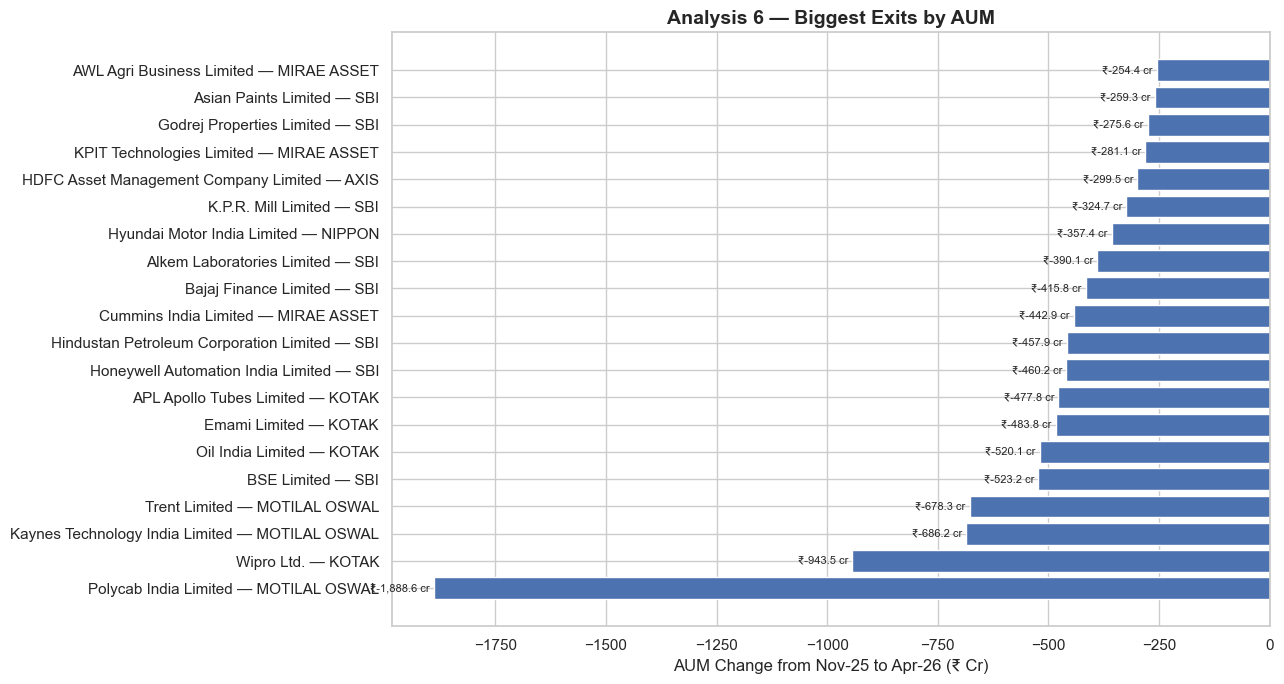

In [57]:
top_exits = entry_exit_df[
    entry_exit_df["Status"] == "Exit"
].sort_values(
    "AUM Change (₹ Cr)",
    ascending=True
).head(20)

top_exits_plot = top_exits.sort_values("AUM Change (₹ Cr)", ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    top_exits_plot["Stock"] + " — " + top_exits_plot["Fund"],
    top_exits_plot["AUM Change (₹ Cr)"]
)

ax.axvline(0, color="black", linewidth=0.8)

ax.bar_label(
    bars,
    labels=[f"₹{v:,.1f} cr" for v in top_exits_plot["AUM Change (₹ Cr)"]],
    padding=3,
    fontsize=8
)

ax.set_title(
    "Analysis 6 — Biggest Exits by AUM",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("AUM Change from Nov-25 to Apr-26 (₹ Cr)")

plt.subplots_adjust(left=0.40, right=0.95)
plt.tight_layout()
plt.show()

In [58]:
# ⚰️ Stocks Exited from Multiple Funds

multi_exits = (
    entry_exit_df[entry_exit_df["Status"] == "Exit"]
    .groupby("Stock")
    .agg(
        Number_of_Funds_Exited=("Fund", "nunique"),
        Funds_Exited=("Fund", lambda x: ", ".join(sorted(x.unique()))),
        Total_Exited_AUM_Cr=("Start AUM (₹ Cr)", "sum")
    )
    .reset_index()
)

# Keep only stocks exited by more than 1 fund
multi_exits = multi_exits[
    multi_exits["Number_of_Funds_Exited"] >= 2
]

multi_exits = multi_exits.sort_values(
    ["Number_of_Funds_Exited", "Total_Exited_AUM_Cr"],
    ascending=False
)

print("⚰️ Stocks Exited from Multiple Funds:")
display(
    multi_exits[
        ["Stock", "Number_of_Funds_Exited", "Funds_Exited", "Total_Exited_AUM_Cr"]
    ].reset_index(drop=True)
)

⚰️ Stocks Exited from Multiple Funds:


,Stock,Number_of_Funds_Exited,Funds_Exited,Total_Exited_AUM_Cr
0,Kaynes Technology India Limited,3,"AXIS, EDELWEISS, MOTILAL OSWAL",832.85
1,Godrej Properties Limited,3,"AXIS, EDELWEISS, SBI",426.29
2,Mphasis Limited,3,"EDELWEISS, HSBC, MIRAE ASSET",249.28
3,HDB Financial Services Limited,3,"AXIS, EDELWEISS, HSBC",132.93
4,Trent Limited,2,"HSBC, MOTILAL OSWAL",678.46
5,Bajaj Finance Limited,2,"HSBC, SBI",573.91
6,Oil India Limited,2,"AXIS, KOTAK",555.54
7,BSE Limited,2,"MIRAE ASSET, SBI",544.56
8,Honeywell Automation India Limited,2,"AXIS, SBI",518.14
9,HDFC Asset Management Company Limited,2,"AXIS, HSBC",451.32


In [59]:
print("🔥 Stocks Newly Entered in Multiple Funds:")

display(
    multi_new_entries[
        ["Stock", "Number_of_Funds_Entered"]
    ].reset_index(drop=True)
)

print("⚰️ Stocks Exited from Multiple Funds:")

display(
    multi_exits[
        ["Stock", "Number_of_Funds_Exited"]
    ].reset_index(drop=True)
)

🔥 Stocks Newly Entered in Multiple Funds:


,Stock,Number_of_Funds_Entered
0,Shriram Finance Limited,4
1,ICICI Prudential Asset Management Company Limited,4
2,Multi Commodity Exchange of India Limited,3
3,JSW Energy Limited,3
4,Billionbrains Garage Ventures Limited,2
5,ICICI Bank Limited,2
6,Supreme Industries Limited,2
7,ICICI Prudential Life Insurance Company Limited,2
8,Oil India Limited,2
9,Aster DM Healthcare Limited,2


⚰️ Stocks Exited from Multiple Funds:


,Stock,Number_of_Funds_Exited
0,Kaynes Technology India Limited,3
1,Godrej Properties Limited,3
2,Mphasis Limited,3
3,HDB Financial Services Limited,3
4,Trent Limited,2
5,Bajaj Finance Limited,2
6,Oil India Limited,2
7,BSE Limited,2
8,Honeywell Automation India Limited,2
9,HDFC Asset Management Company Limited,2


In [60]:
import yfinance as yf
import pandas as pd
import numpy as np

# Newly entered stocks
entered_stocks = {
    "Shriram Finance Limited": "SHRIRAMFIN.NS",
    "ICICI Prudential Asset Management Company Limited": "ICICIAMC.NS",
    "Multi Commodity Exchange of India Limited": "MCX.NS",
    "JSW Energy Limited": "JSWENERGY.NS",
    "Billionbrains Garage Ventures Limited": "GROWW.NS",
    "ICICI Bank Limited": "ICICIBANK.NS",
    "Supreme Industries Limited": "SUPREMEIND.NS",
    "ICICI Prudential Life Insurance Company Limited": "ICICIPRULI.NS",
    "Oil India Limited": "OIL.NS",
    "Aster DM Healthcare Limited": "ASTERDM.NS",
    "Polycab India Limited": "POLYCAB.NS",
    "Mankind Pharma Limited": "MANKIND.NS",
    "National Aluminium Company Limited": "NATIONALUM.NS",
    "Wakefit Innovations Limited": "WAKEFIT.NS"
}

# Exited stocks
exited_stocks = {
    "Kaynes Technology India Limited": "KAYNES.NS",
    "Godrej Properties Limited": "GODREJPROP.NS",
    "Mphasis Limited": "MPHASIS.NS",
    "HDB Financial Services Limited": "HDBFS.NS",
    "Trent Limited": "TRENT.NS",
    "Bajaj Finance Limited": "BAJFINANCE.NS",
    "Oil India Limited": "OIL.NS",
    "BSE Limited": "BSE.NS",
    "Honeywell Automation India Limited": "HONAUT.NS",
    "HDFC Asset Management Company Limited": "HDFCAMC.NS",
    "Oberoi Realty Limited": "OBEROIRLTY.NS",
    "Cohance Lifesciences Limited": "COHANCE.NS"
}

# Combine with category
stocks_all = []

for stock, ticker in entered_stocks.items():
    stocks_all.append({
        "Stock": stock,
        "Ticker": ticker,
        "Flow Category": "New Entry",
        "Entry Dummy": 1,
        "Exit Dummy": 0
    })

for stock, ticker in exited_stocks.items():
    stocks_all.append({
        "Stock": stock,
        "Ticker": ticker,
        "Flow Category": "Exit",
        "Entry Dummy": 0,
        "Exit Dummy": 1
    })

stocks_all_df = pd.DataFrame(stocks_all)

# 6-month return period
start_date = "2025-10-31"
end_date = "2026-04-30"

# Download buffer
start_download = "2025-10-20"
end_download = "2026-05-05"


def get_nearest_price(price_series, target_date):
    """
    Use nearest available trading price on or before target date.
    """
    target_date = pd.to_datetime(target_date)
    available = price_series[price_series.index <= target_date]

    if available.empty:
        return np.nan, None

    return available.iloc[-1], available.index[-1].date()


six_month_results = []

for _, row in stocks_all_df.iterrows():
    stock_name = row["Stock"]
    ticker = row["Ticker"]

    try:
        data = yf.download(
            ticker,
            start=start_download,
            end=end_download,
            auto_adjust=True,
            progress=False,
            multi_level_index=False
        )

        if data.empty:
            six_month_results.append({
                "Stock": stock_name,
                "Ticker": ticker,
                "Flow Category": row["Flow Category"],
                "Entry Dummy": row["Entry Dummy"],
                "Exit Dummy": row["Exit Dummy"],
                "6M Start Date": None,
                "6M Start Price": np.nan,
                "6M End Date": None,
                "6M End Price": np.nan,
                "6M Return (%)": np.nan,
                "Error": "No data found"
            })
            continue

        price = data["Close"].dropna()

        start_price, actual_start_date = get_nearest_price(price, start_date)
        end_price, actual_end_date = get_nearest_price(price, end_date)

        if pd.isna(start_price) or pd.isna(end_price):
            six_m_return = np.nan
        else:
            six_m_return = ((end_price / start_price) - 1) * 100

        six_month_results.append({
            "Stock": stock_name,
            "Ticker": ticker,
            "Flow Category": row["Flow Category"],
            "Entry Dummy": row["Entry Dummy"],
            "Exit Dummy": row["Exit Dummy"],
            "6M Start Date": actual_start_date,
            "6M Start Price": round(float(start_price), 2) if pd.notna(start_price) else np.nan,
            "6M End Date": actual_end_date,
            "6M End Price": round(float(end_price), 2) if pd.notna(end_price) else np.nan,
            "6M Return (%)": round(float(six_m_return), 2) if pd.notna(six_m_return) else np.nan,
            "Error": None
        })

    except Exception as e:
        six_month_results.append({
            "Stock": stock_name,
            "Ticker": ticker,
            "Flow Category": row["Flow Category"],
            "Entry Dummy": row["Entry Dummy"],
            "Exit Dummy": row["Exit Dummy"],
            "6M Start Date": None,
            "6M Start Price": np.nan,
            "6M End Date": None,
            "6M End Price": np.nan,
            "6M Return (%)": np.nan,
            "Error": str(e)
        })


six_m_return_df = pd.DataFrame(six_month_results)

# Sort by 6M return
six_m_return_df = six_m_return_df.sort_values(
    by="6M Return (%)",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

display(six_m_return_df)

six_m_return_df.to_csv(
    "entry_exit_stocks_6m_return.csv",
    index=False
)

,Stock,Ticker,Flow Category,Entry Dummy,Exit Dummy,6M Start Date,6M Start Price,6M End Date,6M End Price,6M Return (%),Error
0,National Aluminium Company Limited,NATIONALUM.NS,New Entry,1,0,2025-10-31,226.67,2026-04-30,397.32,75.28,None
1,Multi Commodity Exchange of India Limited,MCX.NS,New Entry,1,0,2025-10-31,1848.70,2026-04-30,2971.50,60.73,None
2,BSE Limited,BSE.NS,Exit,0,1,2025-10-31,2479.00,2026-04-30,3640.50,46.85,None
3,Shriram Finance Limited,SHRIRAMFIN.NS,New Entry,1,0,2025-10-31,744.36,2026-04-30,937.35,25.93,None
4,Oil India Limited,OIL.NS,Exit,0,1,2025-10-31,423.40,2026-04-30,490.80,15.92,None
5,Oil India Limited,OIL.NS,New Entry,1,0,2025-10-31,423.40,2026-04-30,490.80,15.92,None
6,JSW Energy Limited,JSWENERGY.NS,New Entry,1,0,2025-10-31,527.45,2026-04-30,561.15,6.39,None
7,Polycab India Limited,POLYCAB.NS,New Entry,1,0,2025-10-31,7704.00,2026-04-30,8110.50,5.28,None
8,Aster DM Healthcare Limited,ASTERDM.NS,New Entry,1,0,2025-10-31,675.09,2026-04-30,701.05,3.84,None
9,HDFC Asset Management Company Limited,HDFCAMC.NS,Exit,0,1,2025-10-31,2689.50,2026-04-30,2712.60,0.86,None


In [61]:
# --- Manual correction for newly listed stocks ---

manual_start_data = {
    "ICICI Prudential Asset Management Company Limited": {
        "Start Date": "2025-12-19",
        "Start Price": 2585.90
    },

    # Fill these two manually from NSE/Yahoo/your source
    "Billionbrains Garage Ventures Limited": {
        "Start Date": "2025-11-14",
        "Start Price": 148.53
    },

    "Wakefit Innovations Limited": {
        "Start Date": "2025-12-19",
        "Start Price": 192.32
    }
}


for stock, info in manual_start_data.items():

    mask = six_m_return_df["Stock"] == stock

    if mask.sum() == 0:
        print(f"Stock not found: {stock}")
        continue

    start_date_manual = info["Start Date"]
    start_price_manual = info["Start Price"]

    six_m_return_df.loc[mask, "6M Start Date"] = pd.to_datetime(
        start_date_manual, errors="coerce"
    ).date()

    six_m_return_df.loc[mask, "6M Start Price"] = start_price_manual

    # Recalculate return only if start price and end price are available
    if pd.notna(start_price_manual):

        six_m_return_df.loc[mask, "6M Return (%)"] = (
            (
                six_m_return_df.loc[mask, "6M End Price"].astype(float)
                / float(start_price_manual)
            ) - 1
        ) * 100

        six_m_return_df.loc[mask, "6M Return (%)"] = six_m_return_df.loc[
            mask, "6M Return (%)"
        ].round(2)

    six_m_return_df.loc[mask, "Return Note"] = "Manual start price used"


display(
    six_m_return_df[
        six_m_return_df["Stock"].isin(manual_start_data.keys())
    ]
)

,Stock,Ticker,Flow Category,Entry Dummy,Exit Dummy,6M Start Date,6M Start Price,6M End Date,6M End Price,6M Return (%),Error,Return Note
23,ICICI Prudential Asset Management Company Limited,ICICIAMC.NS,New Entry,1,0,2025-12-19,2585.90,2026-04-30,3290.20,27.24,None,Manual start price used
24,Billionbrains Garage Ventures Limited,GROWW.NS,New Entry,1,0,2025-11-14,148.53,2026-04-30,214.99,44.75,None,Manual start price used
25,Wakefit Innovations Limited,WAKEFIT.NS,New Entry,1,0,2025-12-19,192.32,2026-04-30,138.05,-28.22,None,Manual start price used


In [62]:
import pandas as pd
import numpy as np

# Make copy
portfolio_df = six_m_return_df.copy()

# Convert return to numeric
portfolio_df["6M Return (%)"] = pd.to_numeric(
    portfolio_df["6M Return (%)"],
    errors="coerce"
)

# Drop missing returns
portfolio_df_clean = portfolio_df.dropna(subset=["6M Return (%)"]).copy()

# Equal-weight portfolio return by category
portfolio_summary = portfolio_df_clean.groupby("Flow Category").agg(
    Stock_Count=("Stock", "count"),
    Equal_Weight_6M_Return=("6M Return (%)", "mean"),
    Median_6M_Return=("6M Return (%)", "median"),
    Best_Return=("6M Return (%)", "max"),
    Worst_Return=("6M Return (%)", "min")
).round(2).reset_index()

display(portfolio_summary)

,Flow Category,Stock_Count,Equal_Weight_6M_Return,Median_6M_Return,Best_Return,Worst_Return
0,Exit,12,-8.53,-10.96,46.85,-39.68
1,New Entry,14,14.82,5.84,75.28,-28.22


In [63]:
# Equal weights within each category
portfolio_df_clean["Equal Weight"] = portfolio_df_clean.groupby(
    "Flow Category"
)["Stock"].transform(lambda x: 1 / len(x))

# Weighted contribution
portfolio_df_clean["Weighted Return Contribution"] = (
    portfolio_df_clean["Equal Weight"] * portfolio_df_clean["6M Return (%)"]
)

# Detailed portfolio table
portfolio_detail = portfolio_df_clean[
    [
        "Stock",
        "Ticker",
        "Flow Category",
        "Entry Dummy",
        "Exit Dummy",
        "6M Return (%)",
        "Equal Weight",
        "Weighted Return Contribution"
    ]
].copy()

portfolio_detail = portfolio_detail.sort_values(
    ["Flow Category", "6M Return (%)"],
    ascending=[True, False]
).reset_index(drop=True)

display(portfolio_detail)

portfolio_detail.to_csv(
    "entry_exit_6m_equal_weight_portfolio_detail.csv",
    index=False
)

,Stock,Ticker,Flow Category,Entry Dummy,Exit Dummy,6M Return (%),Equal Weight,Weighted Return Contribution
0,BSE Limited,BSE.NS,Exit,0,1,46.85,0.083333,3.904167
1,Oil India Limited,OIL.NS,Exit,0,1,15.92,0.083333,1.326667
2,HDFC Asset Management Company Limited,HDFCAMC.NS,Exit,0,1,0.86,0.083333,0.071667
3,Oberoi Realty Limited,OBEROIRLTY.NS,Exit,0,1,-5.99,0.083333,-0.499167
4,Bajaj Finance Limited,BAJFINANCE.NS,Exit,0,1,-10.15,0.083333,-0.845833
5,HDB Financial Services Limited,HDBFS.NS,Exit,0,1,-10.21,0.083333,-0.850833
6,Trent Limited,TRENT.NS,Exit,0,1,-11.71,0.083333,-0.975833
7,Honeywell Automation India Limited,HONAUT.NS,Exit,0,1,-14.97,0.083333,-1.247500
8,Mphasis Limited,MPHASIS.NS,Exit,0,1,-17.64,0.083333,-1.470000
9,Godrej Properties Limited,GODREJPROP.NS,Exit,0,1,-19.79,0.083333,-1.649167


In [64]:
entry_return = portfolio_summary.loc[
    portfolio_summary["Flow Category"] == "New Entry",
    "Equal_Weight_6M_Return"
].iloc[0]

exit_return = portfolio_summary.loc[
    portfolio_summary["Flow Category"] == "Exit",
    "Equal_Weight_6M_Return"
].iloc[0]

long_short_spread = entry_return - exit_return

final_portfolio_result = pd.DataFrame({
    "Portfolio": [
        "New Entry Equal-Weight Portfolio",
        "Exit Equal-Weight Portfolio",
        "Entry minus Exit Spread"
    ],
    "6M Return (%)": [
        entry_return,
        exit_return,
        round(long_short_spread, 2)
    ]
})

display(final_portfolio_result)

final_portfolio_result.to_csv(
    "entry_exit_6m_equal_weight_portfolio_summary.csv",
    index=False
)

,Portfolio,6M Return (%)
0,New Entry Equal-Weight Portfolio,14.82
1,Exit Equal-Weight Portfolio,-8.53
2,Entry minus Exit Spread,23.35


In [65]:
import pandas as pd
import numpy as np

# --- 1. Entered and exited stock counts ---

entered_counts = pd.DataFrame({
    "Stock": [
        "Shriram Finance Limited",
        "ICICI Prudential Asset Management Company Limited",
        "Multi Commodity Exchange of India Limited",
        "JSW Energy Limited",
        "Billionbrains Garage Ventures Limited",
        "ICICI Bank Limited",
        "Supreme Industries Limited",
        "ICICI Prudential Life Insurance Company Limited",
        "Oil India Limited",
        "Aster DM Healthcare Limited",
        "Polycab India Limited",
        "Mankind Pharma Limited",
        "National Aluminium Company Limited",
        "Wakefit Innovations Limited"
    ],
    "Number_of_Funds": [4, 4, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
    "Flow Category": "New Entry"
})

exited_counts = pd.DataFrame({
    "Stock": [
        "Kaynes Technology India Limited",
        "Godrej Properties Limited",
        "Mphasis Limited",
        "HDB Financial Services Limited",
        "Trent Limited",
        "Bajaj Finance Limited",
        "Oil India Limited",
        "BSE Limited",
        "Honeywell Automation India Limited",
        "HDFC Asset Management Company Limited",
        "Oberoi Realty Limited",
        "Cohance Lifesciences Limited"
    ],
    "Number_of_Funds": [3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2],
    "Flow Category": "Exit"
})

fund_count_df = pd.concat(
    [entered_counts, exited_counts],
    ignore_index=True
)

In [66]:
# --- 2. Clean stock names for safe merging ---

def clean_stock_name(x):
    x = str(x).lower()
    x = x.replace("limited", "")
    x = x.replace("ltd", "")
    x = x.replace(".", "")
    x = x.replace("&", "and")
    x = x.replace("-", " ")
    x = x.replace("(", "")
    x = x.replace(")", "")
    x = " ".join(x.split())
    return x


returns_df = six_m_return_df.copy()
returns_df["Clean Stock"] = returns_df["Stock"].apply(clean_stock_name)

fund_count_df["Clean Stock"] = fund_count_df["Stock"].apply(clean_stock_name)


# --- 3. Merge 6M return with number of funds entered/exited ---

weighted_df = returns_df.merge(
    fund_count_df[["Clean Stock", "Number_of_Funds"]],
    on="Clean Stock",
    how="left"
)

weighted_df["6M Return (%)"] = pd.to_numeric(
    weighted_df["6M Return (%)"],
    errors="coerce"
)

weighted_df["Number_of_Funds"] = pd.to_numeric(
    weighted_df["Number_of_Funds"],
    errors="coerce"
)

weighted_df = weighted_df.dropna(
    subset=["6M Return (%)", "Number_of_Funds"]
).copy()

display(weighted_df[
    ["Stock", "Flow Category", "Number_of_Funds", "6M Return (%)"]
])

,Stock,Flow Category,Number_of_Funds,6M Return (%)
0,National Aluminium Company Limited,New Entry,2,75.28
1,Multi Commodity Exchange of India Limited,New Entry,3,60.73
2,BSE Limited,Exit,2,46.85
3,Shriram Finance Limited,New Entry,4,25.93
4,Oil India Limited,Exit,2,15.92
5,Oil India Limited,Exit,2,15.92
6,Oil India Limited,New Entry,2,15.92
7,Oil India Limited,New Entry,2,15.92
8,JSW Energy Limited,New Entry,3,6.39
9,Polycab India Limited,New Entry,2,5.28


In [67]:
# --- 4. Calculate weighted portfolio return by flow category ---

weighted_df["Fund_Count_Weight"] = weighted_df.groupby(
    "Flow Category"
)["Number_of_Funds"].transform(lambda x: x / x.sum())

weighted_df["Weighted_Return_Contribution"] = (
    weighted_df["Fund_Count_Weight"] * weighted_df["6M Return (%)"]
)

weighted_portfolio_summary = weighted_df.groupby("Flow Category").agg(
    Stock_Count=("Stock", "count"),
    Total_Fund_Count=("Number_of_Funds", "sum"),
    Weighted_6M_Return=("Weighted_Return_Contribution", "sum"),
    Equal_Weight_6M_Return=("6M Return (%)", "mean"),
    Median_6M_Return=("6M Return (%)", "median"),
    Best_Return=("6M Return (%)", "max"),
    Worst_Return=("6M Return (%)", "min")
).round(2).reset_index()

display(weighted_portfolio_summary)

,Flow Category,Stock_Count,Total_Fund_Count,Weighted_6M_Return,Equal_Weight_6M_Return,Median_6M_Return,Best_Return,Worst_Return
0,Exit,13,30,-8.67,-6.65,-10.21,46.85,-39.68
1,New Entry,15,36,17.23,14.89,6.39,75.28,-28.22
